Import Libraries

In [440]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import roc_auc_score

Open Data

In [441]:
data = pd.read_csv("D:\python\Heart_Disease\heart_disease_uci.csv")

print(data.head())

   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    0  
4             normal    0  


In [442]:
print(data.columns)

Index(['id', 'age', 'sex', 'dataset', 'cp', 'trestbps', 'chol', 'fbs',
       'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')


Print Shape Data

In [443]:
print(data.shape)

(920, 16)


Print the values ​​of each column

In [444]:
for col in data.columns:
    print('\n', data[col].value_counts())


 id
1      1
2      1
3      1
4      1
5      1
      ..
916    1
917    1
918    1
919    1
920    1
Name: count, Length: 920, dtype: int64

 age
54    51
58    43
55    41
56    38
57    38
52    36
59    35
51    35
62    35
53    33
60    32
61    31
48    31
63    30
50    25
41    24
43    24
46    24
49    22
64    22
65    21
44    19
47    19
42    18
45    18
38    16
67    15
39    15
40    13
66    13
69    13
37    11
35    11
68    10
74     7
34     7
70     7
36     6
71     5
32     5
72     4
29     3
75     3
31     2
77     2
76     2
33     2
28     1
30     1
73     1
Name: count, dtype: int64

 sex
Male      726
Female    194
Name: count, dtype: int64

 dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

 cp
asymptomatic       496
non-anginal        204
atypical angina    174
typical angina      46
Name: count, dtype: int64

 trestbps
120.0    131
130.0    115
140.0    102
110.0     59
150.0    

Remove outlier column

In [445]:
data.drop("id", axis=1, inplace=True)

Print data structure

In [446]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       920 non-null    int64  
 1   sex       920 non-null    object 
 2   dataset   920 non-null    object 
 3   cp        920 non-null    object 
 4   trestbps  861 non-null    float64
 5   chol      890 non-null    float64
 6   fbs       830 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    865 non-null    float64
 9   exang     865 non-null    object 
 10  oldpeak   858 non-null    float64
 11  slope     611 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       920 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 107.9+ KB
None


Mathematical data statistics

In [447]:
print(data.describe())

              age    trestbps        chol      thalch     oldpeak          ca  \
count  920.000000  861.000000  890.000000  865.000000  858.000000  309.000000   
mean    53.510870  132.132404  199.130337  137.545665    0.878788    0.676375   
std      9.424685   19.066070  110.780810   25.926276    1.091226    0.935653   
min     28.000000    0.000000    0.000000   60.000000   -2.600000    0.000000   
25%     47.000000  120.000000  175.000000  120.000000    0.000000    0.000000   
50%     54.000000  130.000000  223.000000  140.000000    0.500000    0.000000   
75%     60.000000  140.000000  268.000000  157.000000    1.500000    1.000000   
max     77.000000  200.000000  603.000000  202.000000    6.200000    3.000000   

              num  
count  920.000000  
mean     0.995652  
std      1.142693  
min      0.000000  
25%      0.000000  
50%      1.000000  
75%      2.000000  
max      4.000000  


Number of empty cells

In [448]:
print(data.isnull().sum())

age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


Duplicates

In [449]:
print(data.duplicated().sum())

data.drop_duplicates(inplace=True)

2


Fill in the blanks

In [450]:
def fill_float(col):
    data[col].fillna(data[col].median(), inplace=True)

for i in data.select_dtypes('float64'):
    fill_float(i)

def fill_object(col):
    data[col].fillna(data[col].mode()[0], inplace=True)

for i in data.select_dtypes('object'):
    fill_object(i)

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\1519796677.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)
C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\1519796677.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

Change data type

In [451]:
data.select_dtypes('float64').round().astype('int64')

data['target'] = data['num'].apply(lambda x: 1 if x > 0 else 0)
data.drop('num', axis=1, inplace=True)

Count chart

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\536111154.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['target'].replace({0: "Negative", 1: "Positive"}, inplace=True)


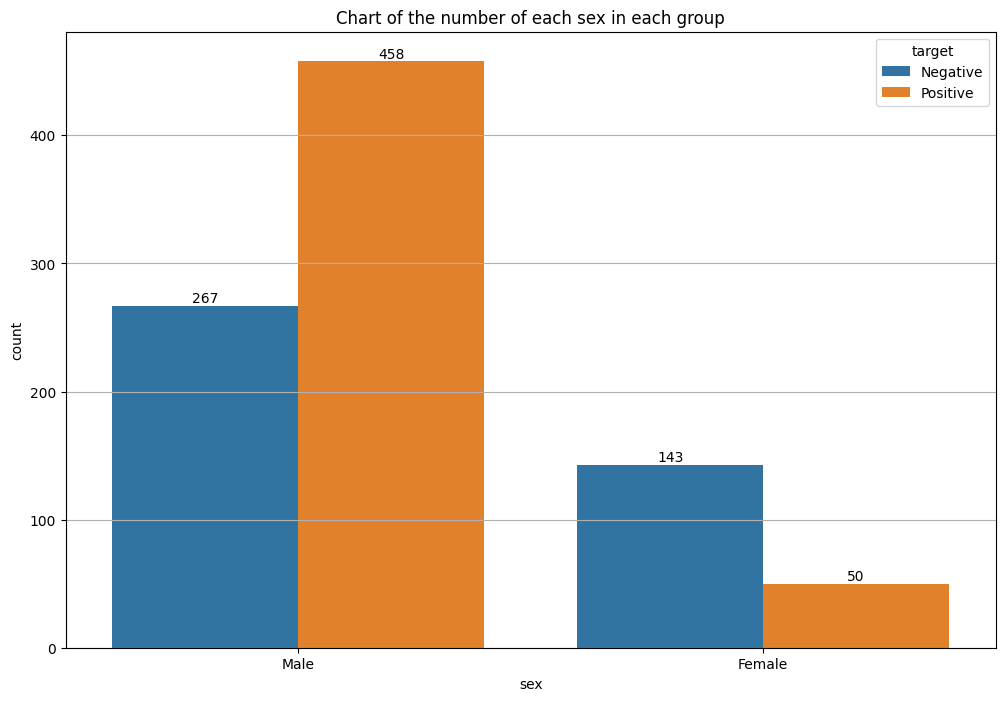

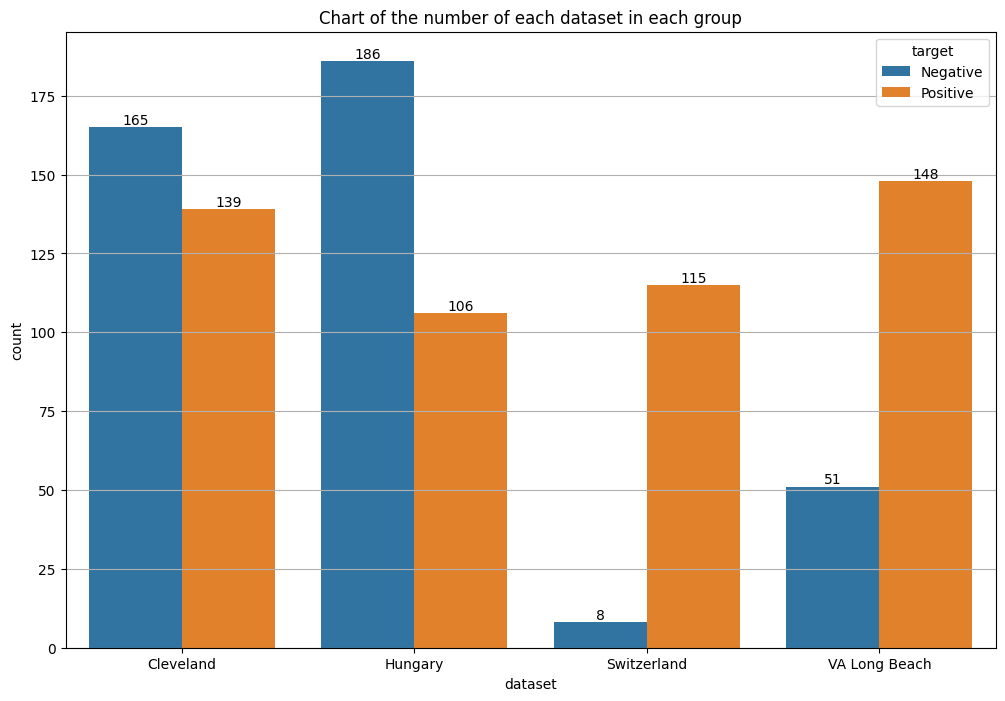

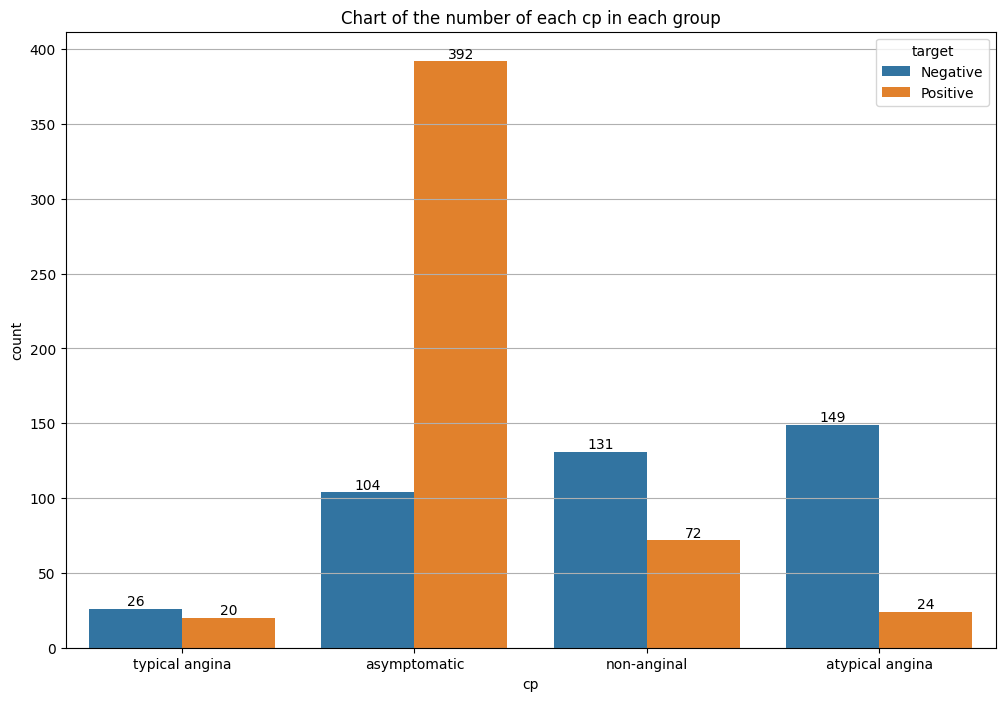

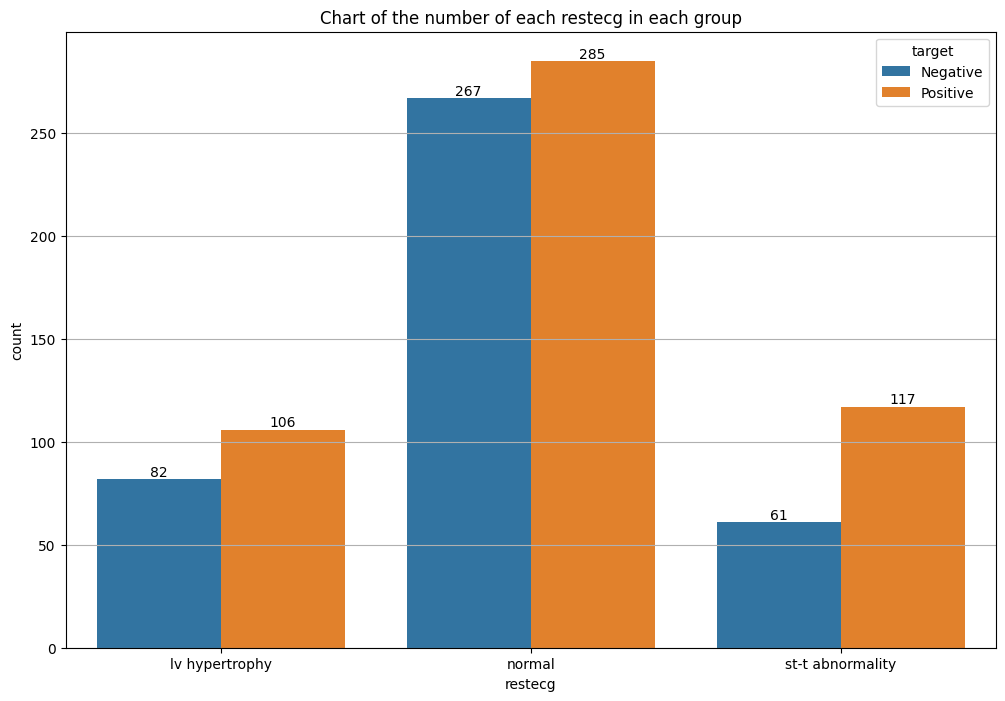

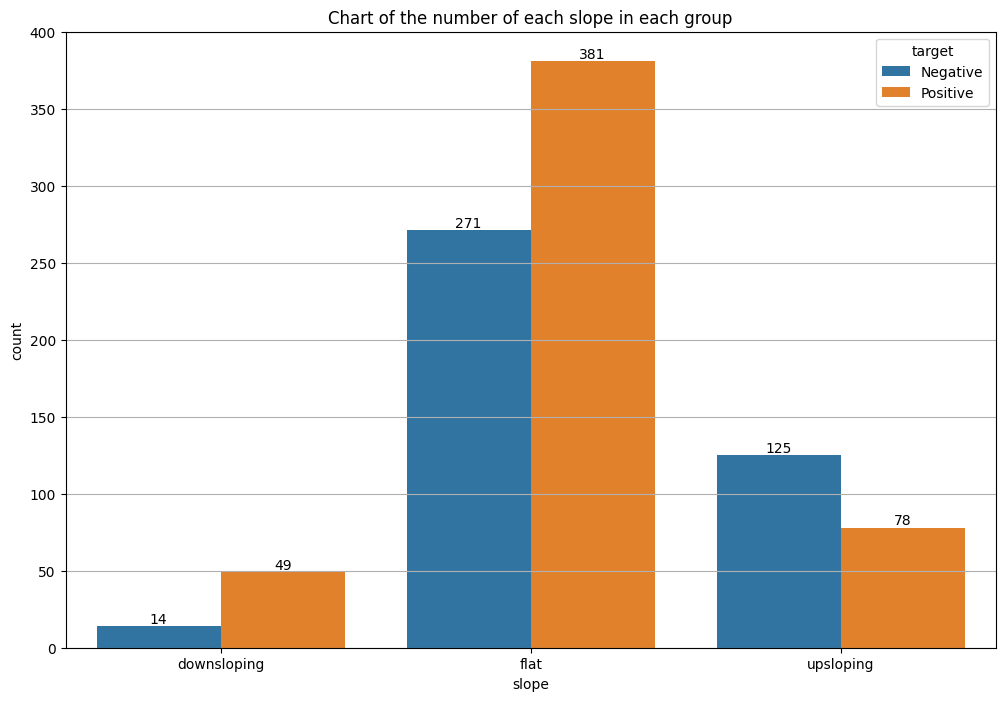

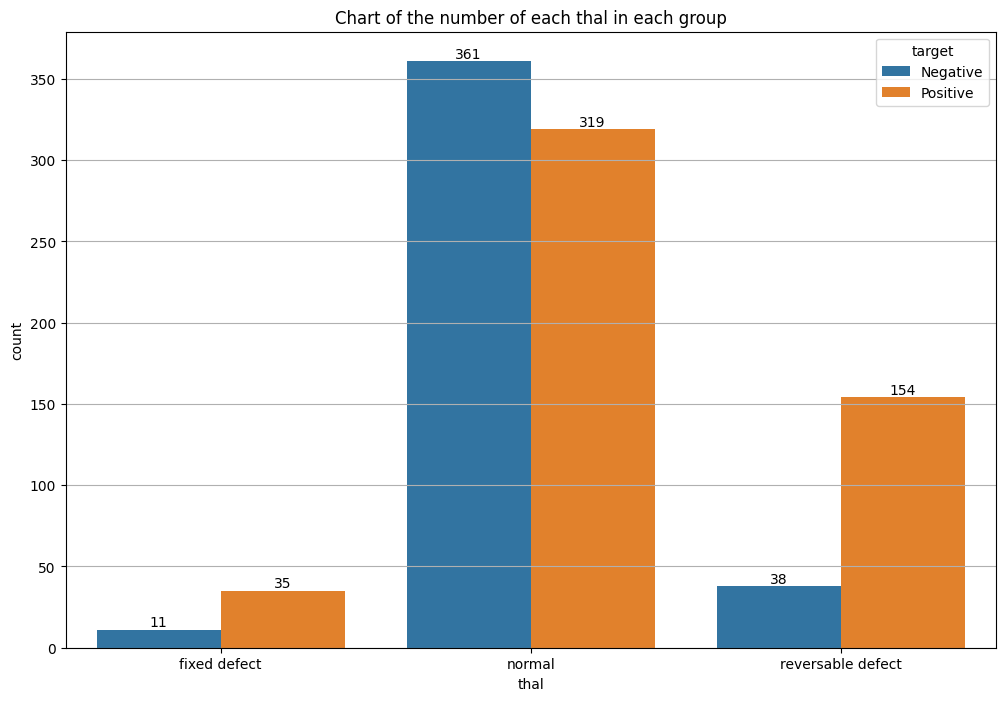

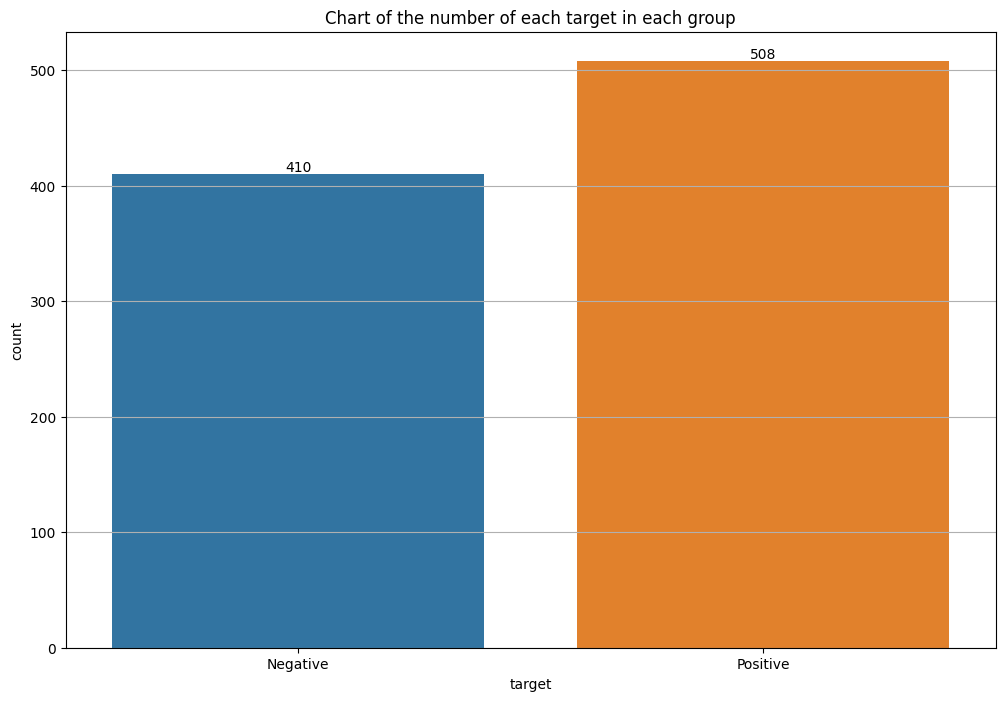

In [452]:
data['target'].replace({0: "Negative", 1: "Positive"}, inplace=True)

def count_chart(col):
    plt.figure(figsize=(12, 8))

    s_cp = sns.countplot(data=data, x=col, hue='target')
    for j in range(len(s_cp.containers)):
        s_cp.bar_label(s_cp.containers[j])

    plt.title(f"Chart of the number of each {col} in each group")
    plt.grid(axis="y")

    plt.show()

for i in data.select_dtypes('object'):
    count_chart(i)

Pie chart

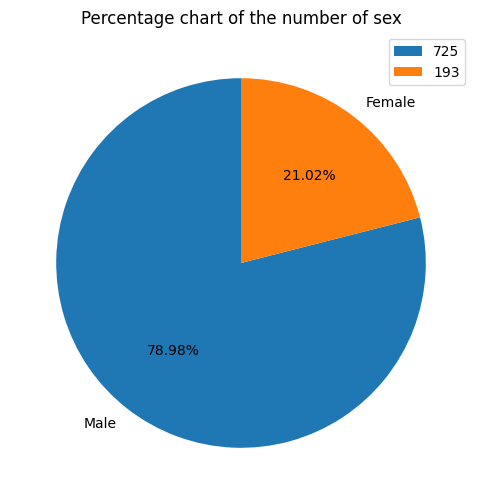

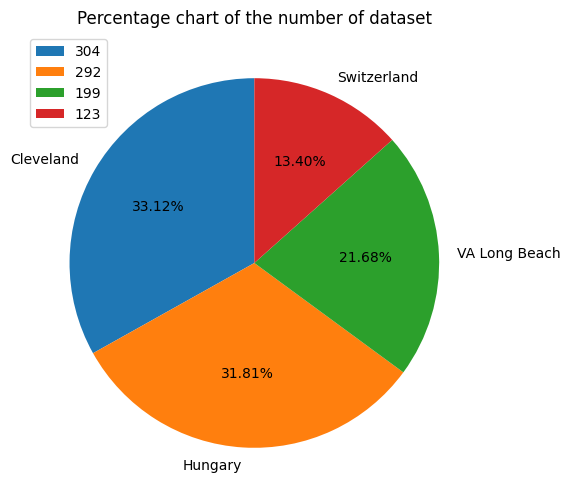

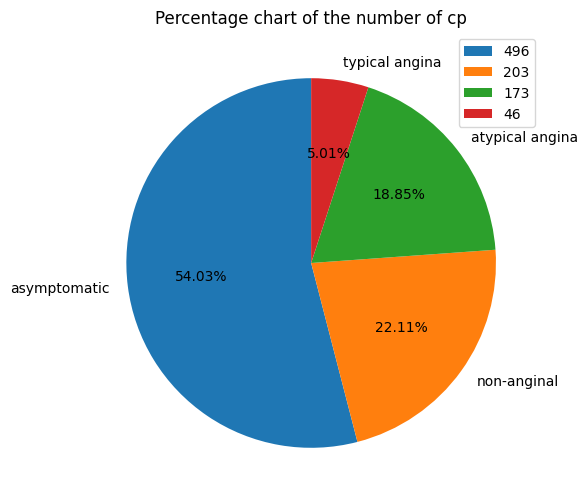

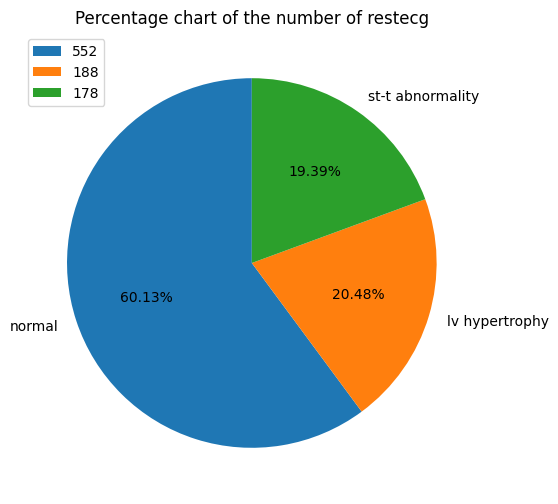

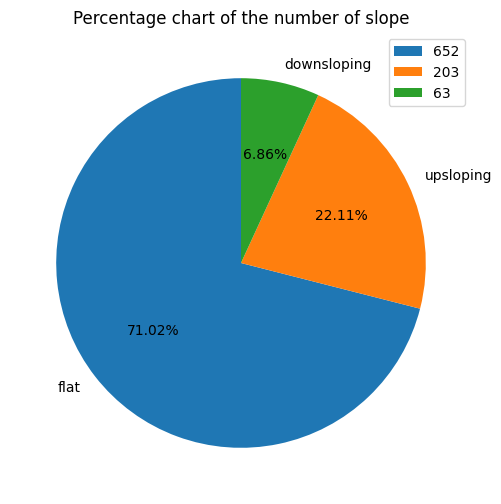

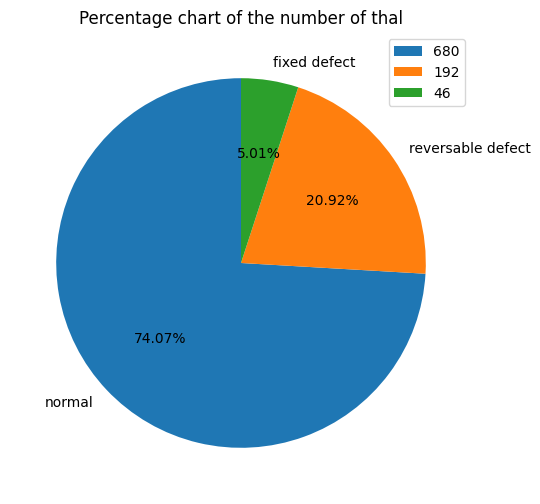

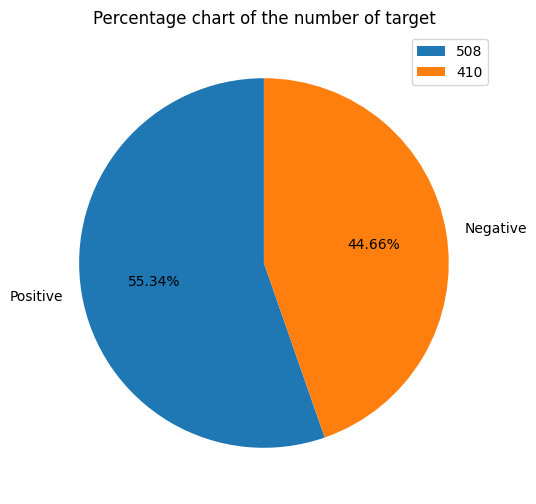

In [453]:
def pie_chart(col):
    plt.figure(figsize=(6, 6))

    plt.pie(data[col].value_counts(), labels=data[col].value_counts().index, autopct='%1.2f%%',
            startangle=90)
    plt.title(f"Percentage chart of the number of {col}")
    plt.legend(data[col].value_counts())

    plt.show()

for i in data.select_dtypes('object'):
    pie_chart(i)

Box chart

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


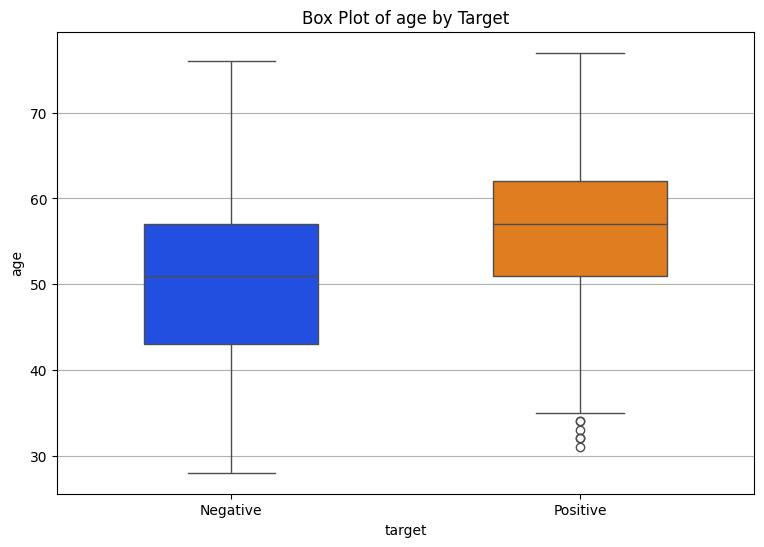

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


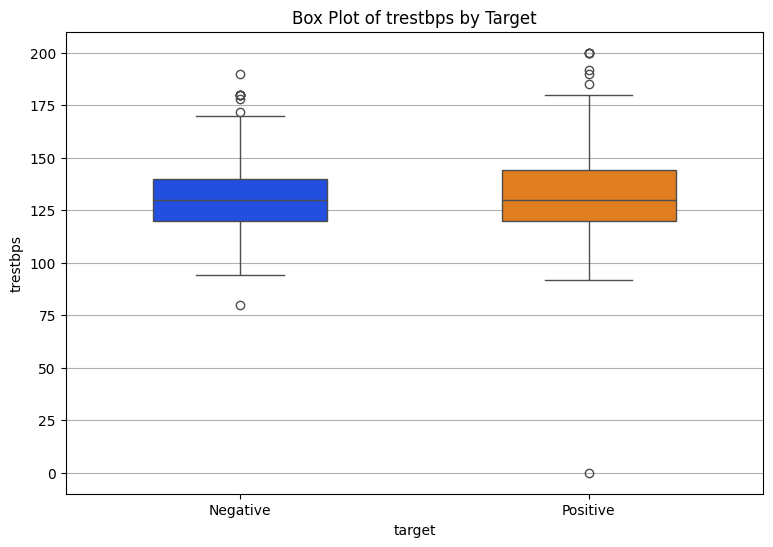

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


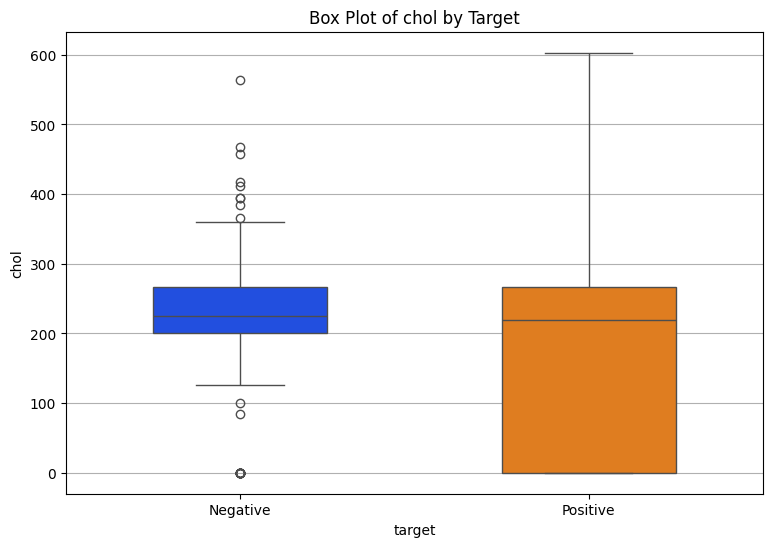

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


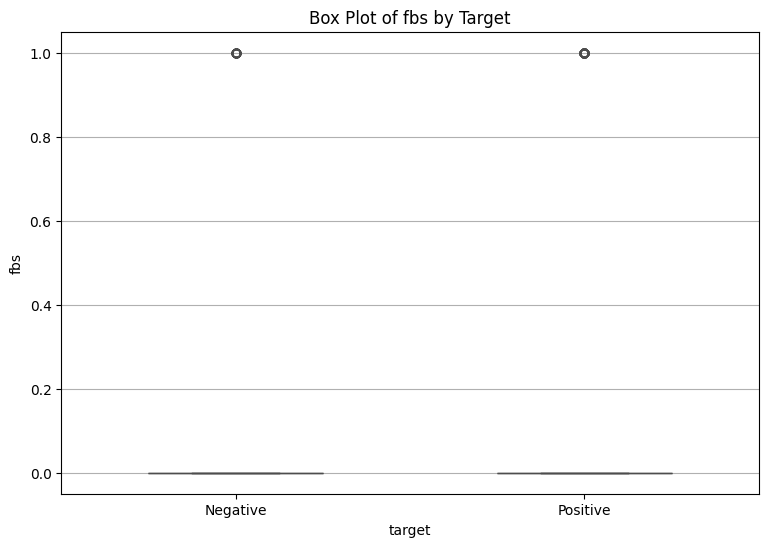

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


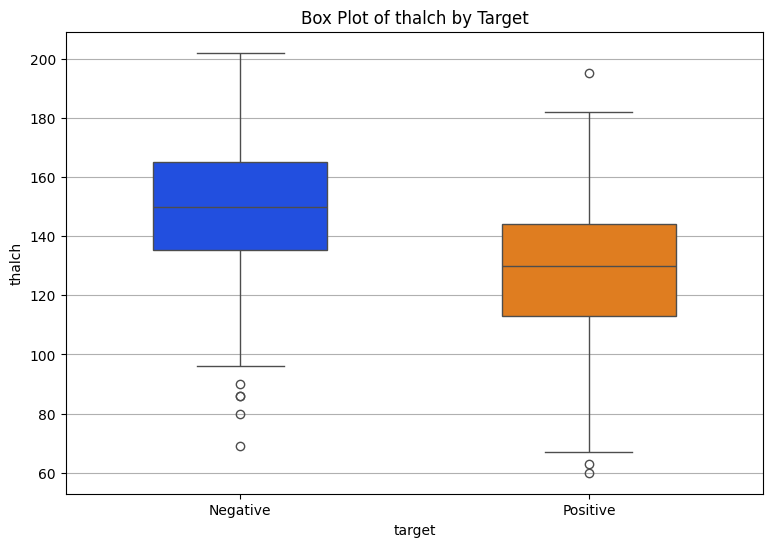

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


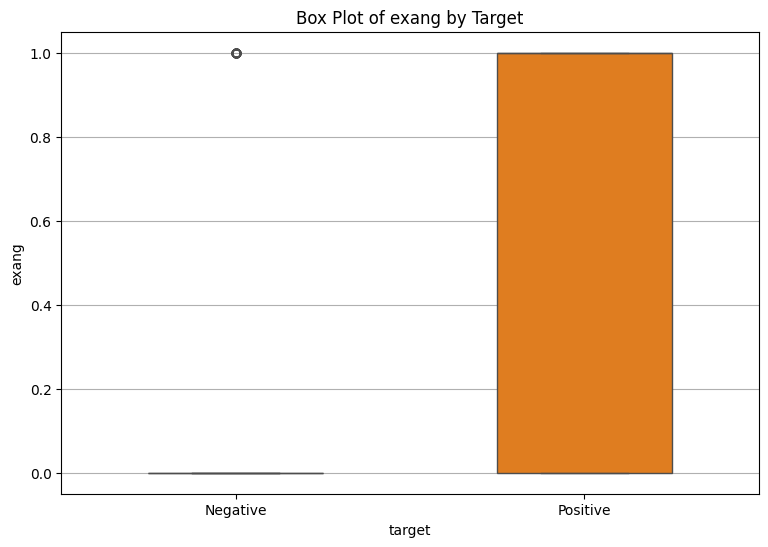

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


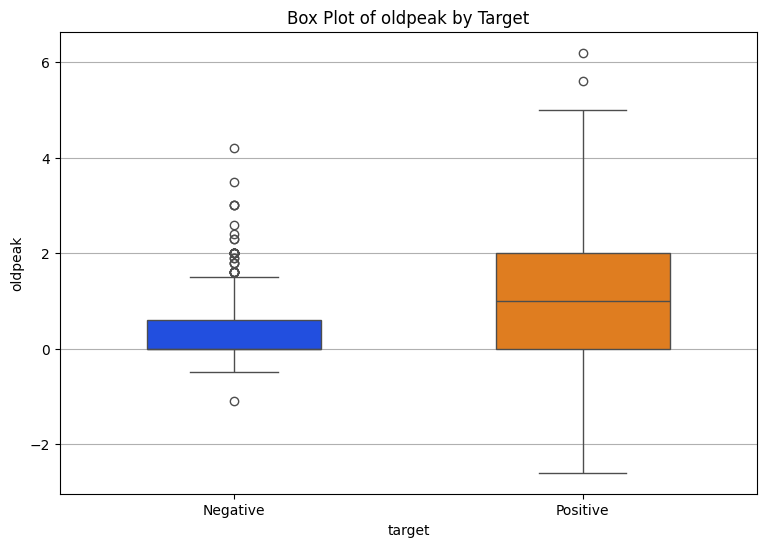

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\3293771907.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')


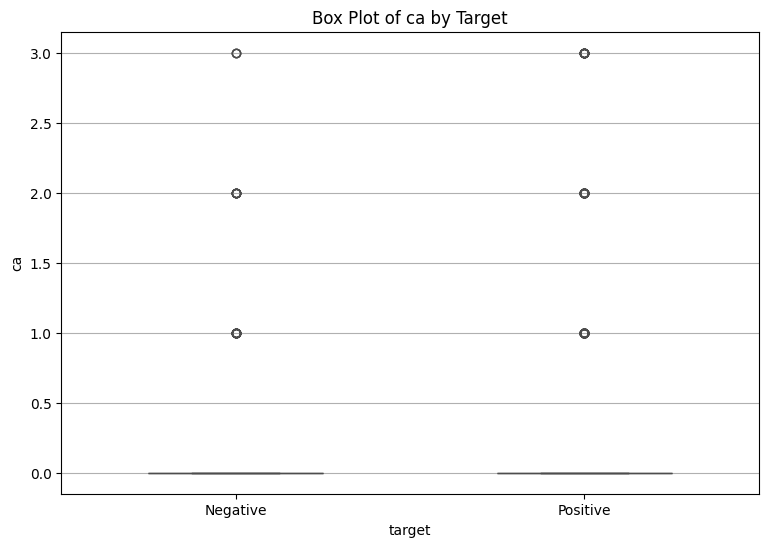

In [454]:
def box_chart(col):
    plt.figure(figsize=(9, 6))
    sns.boxplot(data=data, x='target', y=col, width=0.5, palette='bright')

    plt.grid(axis='y')
    plt.title(f"Box Plot of {col} by Target")

    plt.show()

for i in data.select_dtypes(exclude='object'):
    box_chart(i)

Violin chart

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


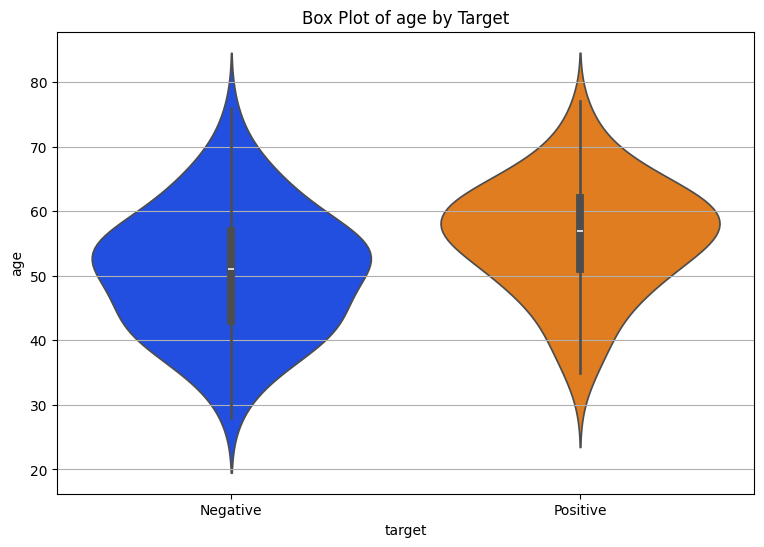

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


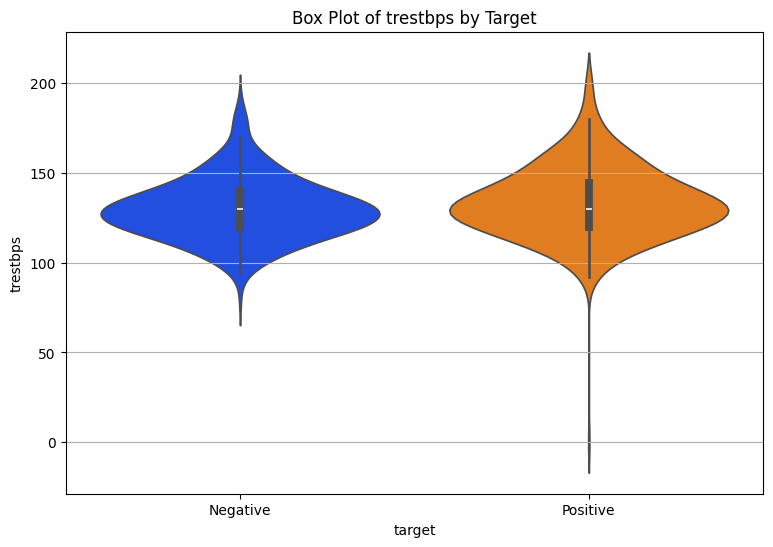

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


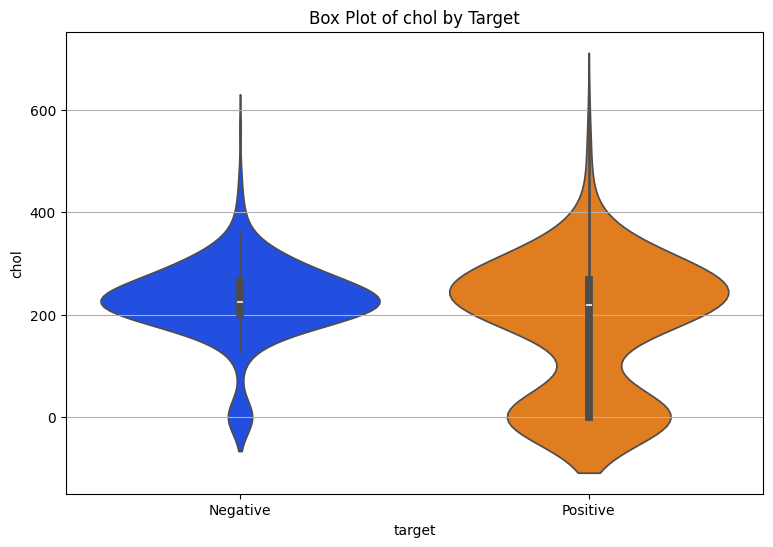

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


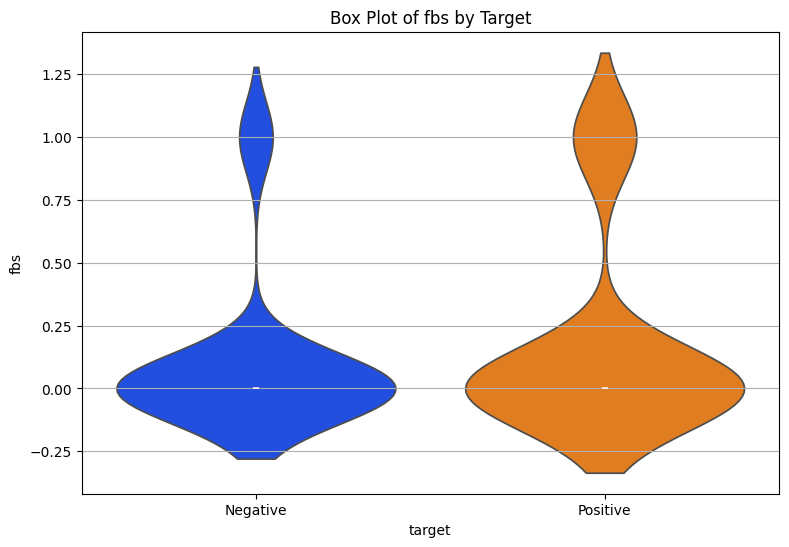

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


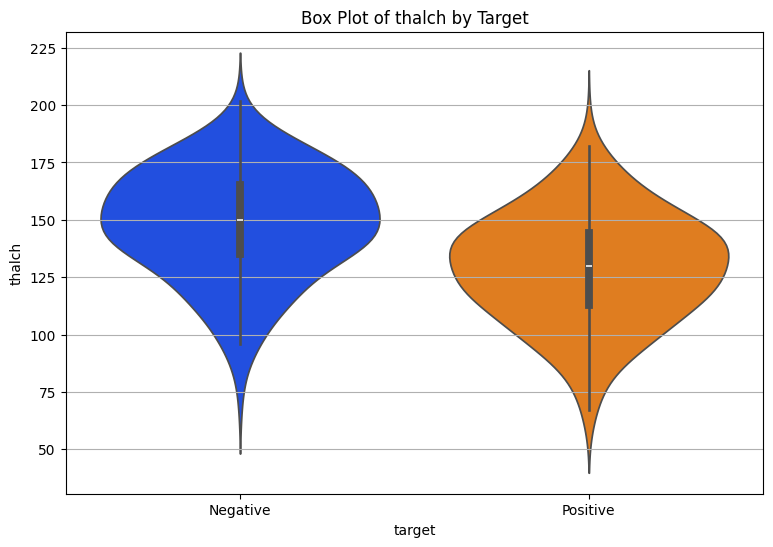

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


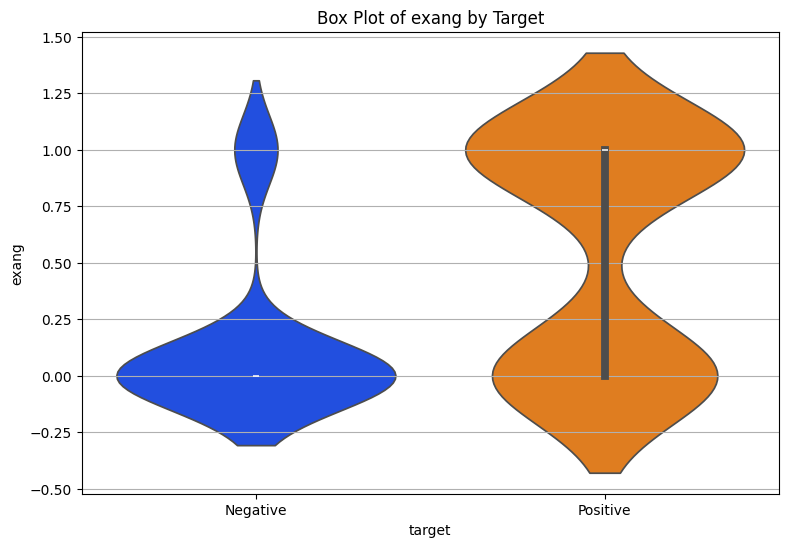

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


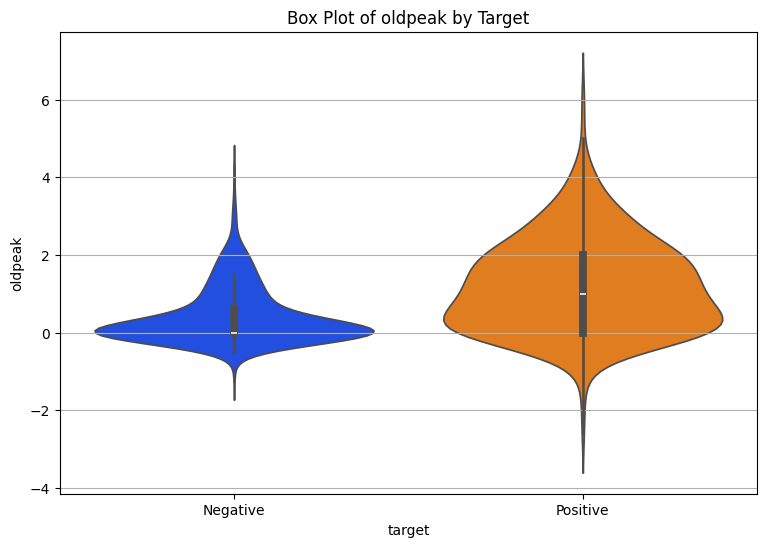

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\996122762.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,


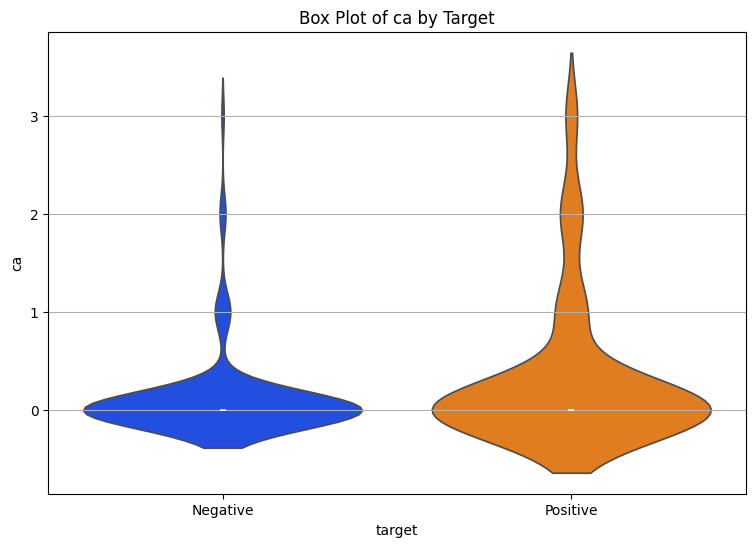

In [455]:
def violin_chart(col):
    plt.figure(figsize=(9, 6))
    sns.violinplot(data=data, x='target', y=col, inner='box', bw_adjust=1.5,
                   palette='bright')

    plt.grid(axis='y')
    plt.title(f"Box Plot of {col} by Target")

    plt.show()

for i in data.select_dtypes(exclude='object'):
    violin_chart(i)

Pairwise Relationships of Heart Disease Features

<Figure size 1200x1200 with 0 Axes>

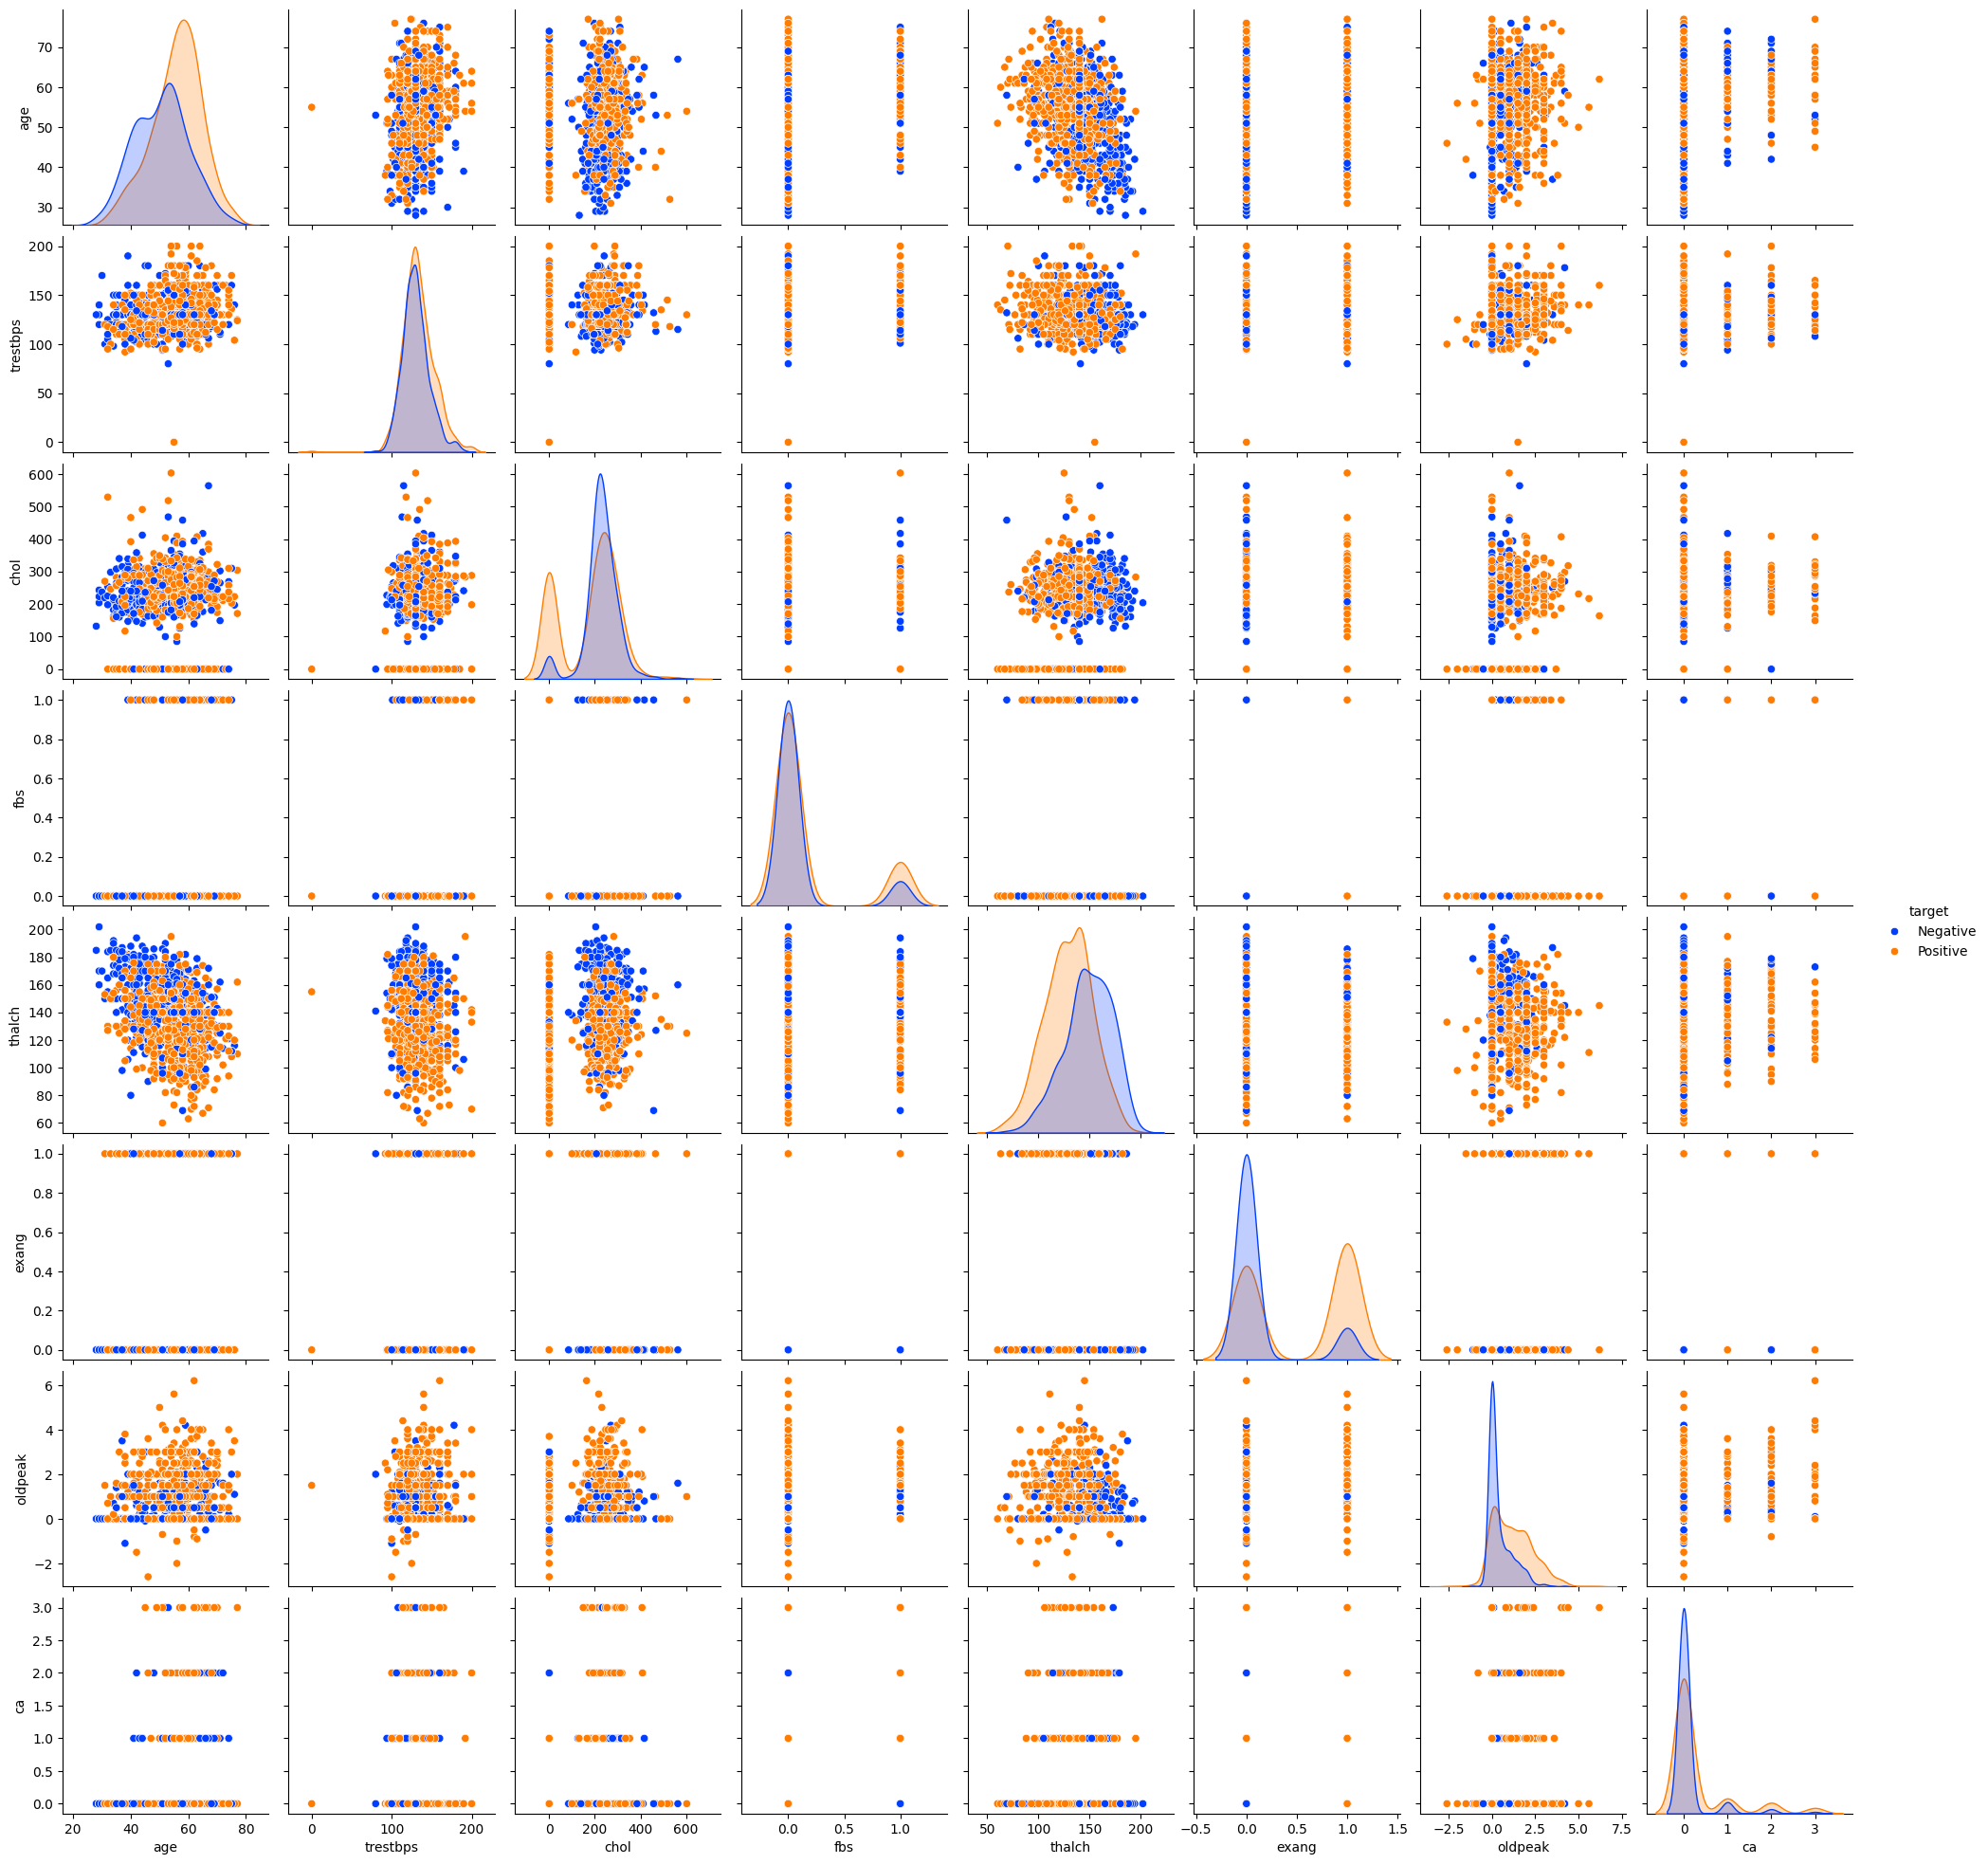

In [456]:
plt.figure(figsize=(12, 12))
sns.pairplot(data=data, hue='target', kind='scatter', palette='bright')
plt.show()

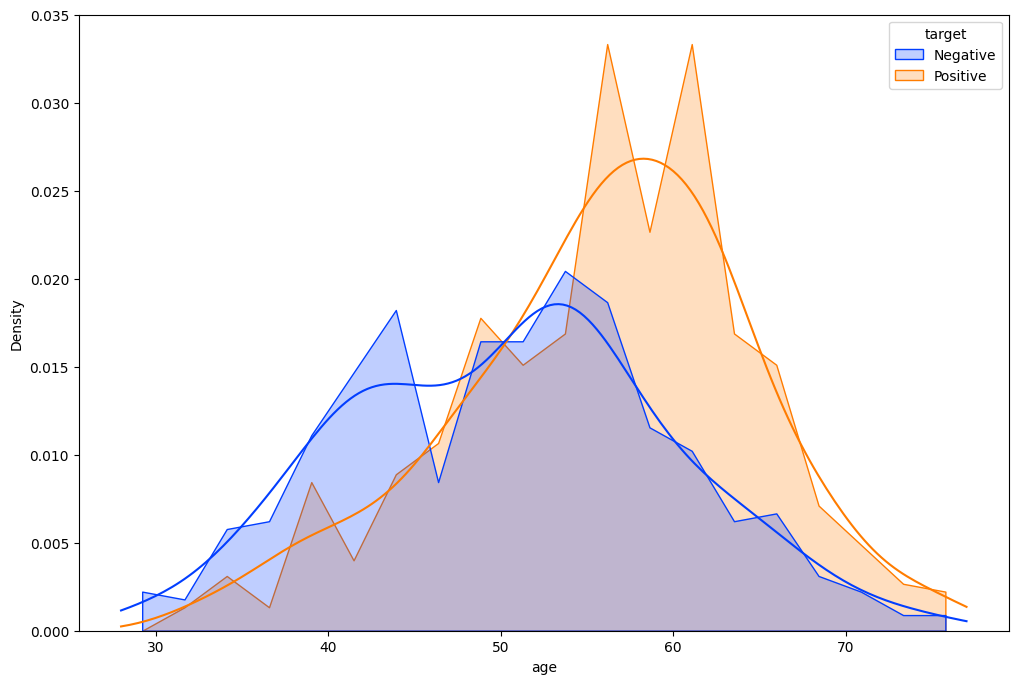

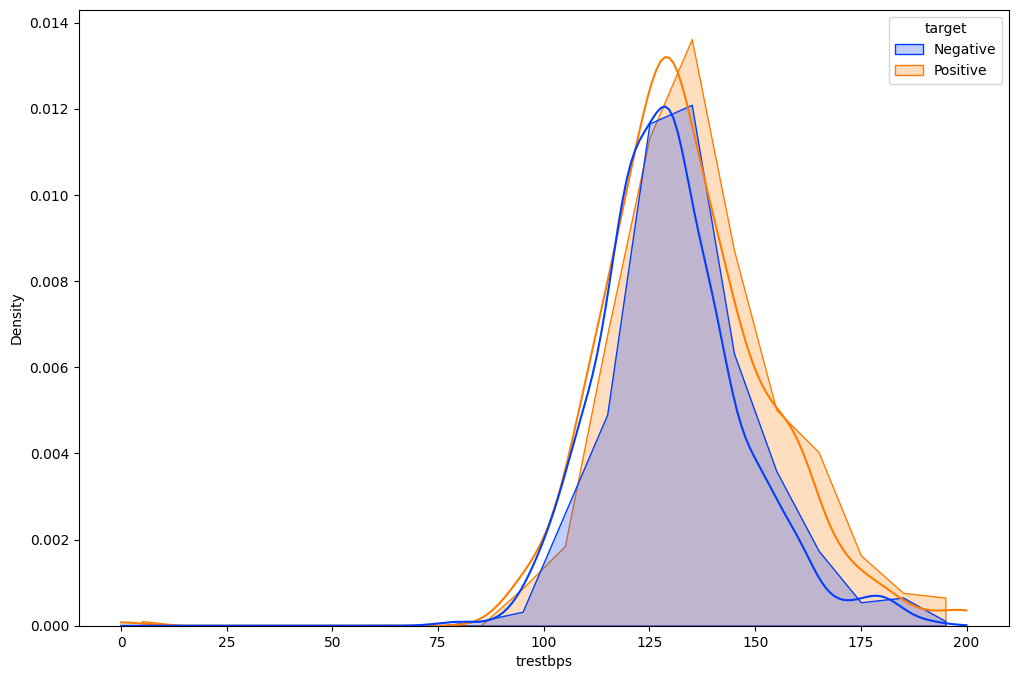

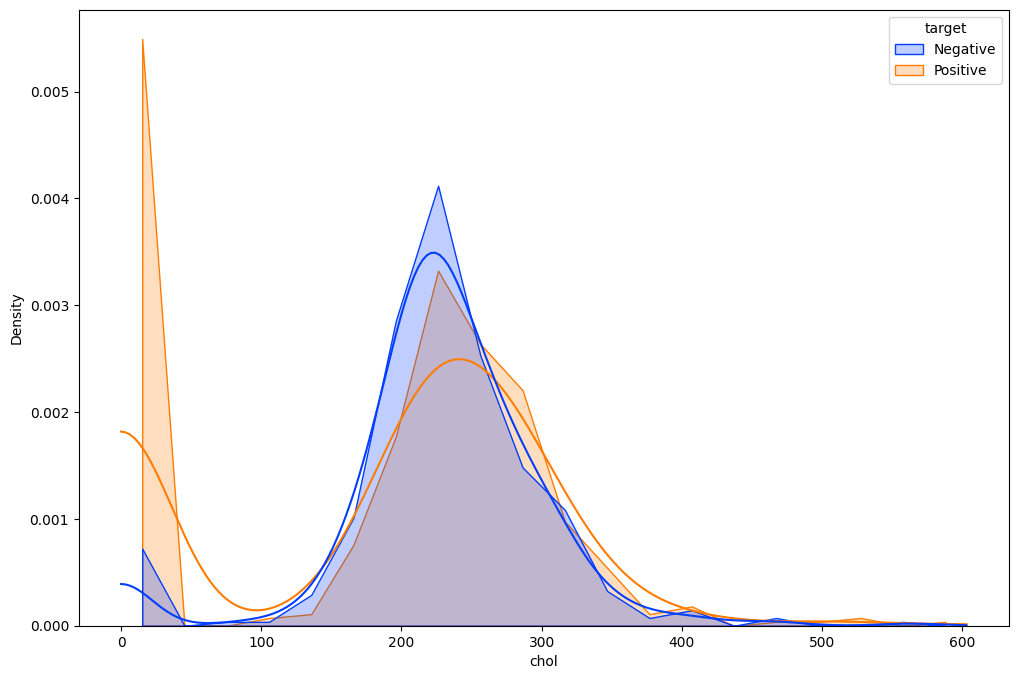

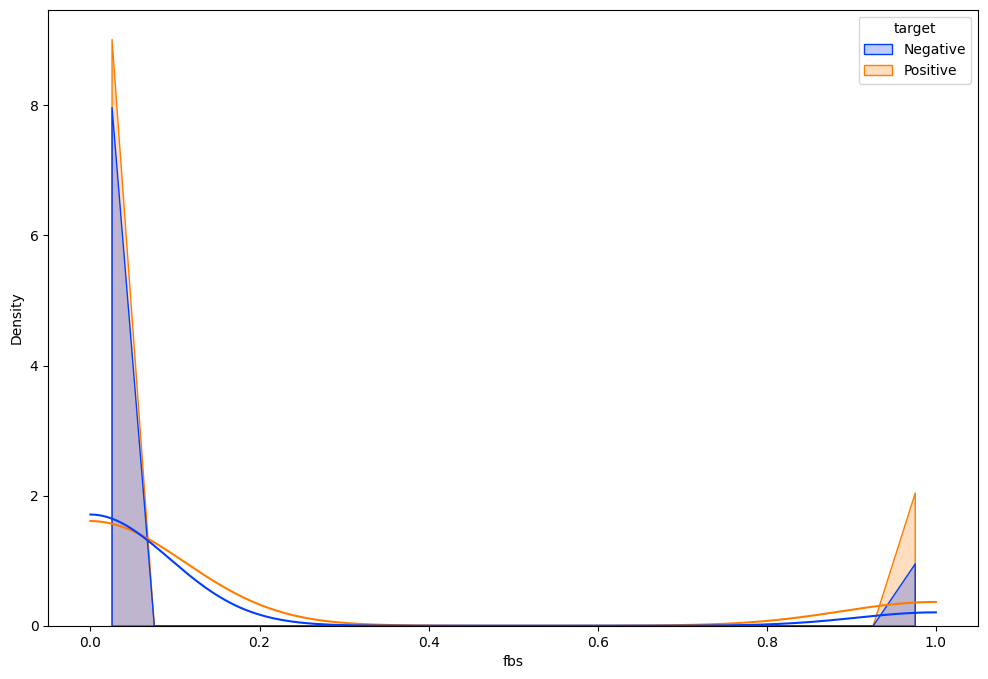

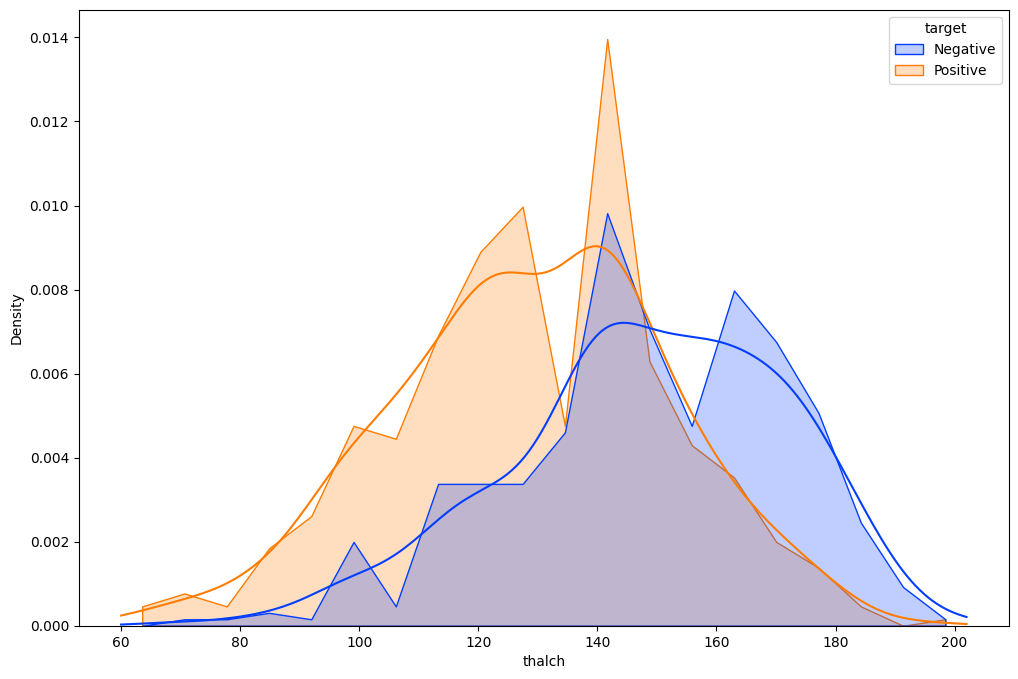

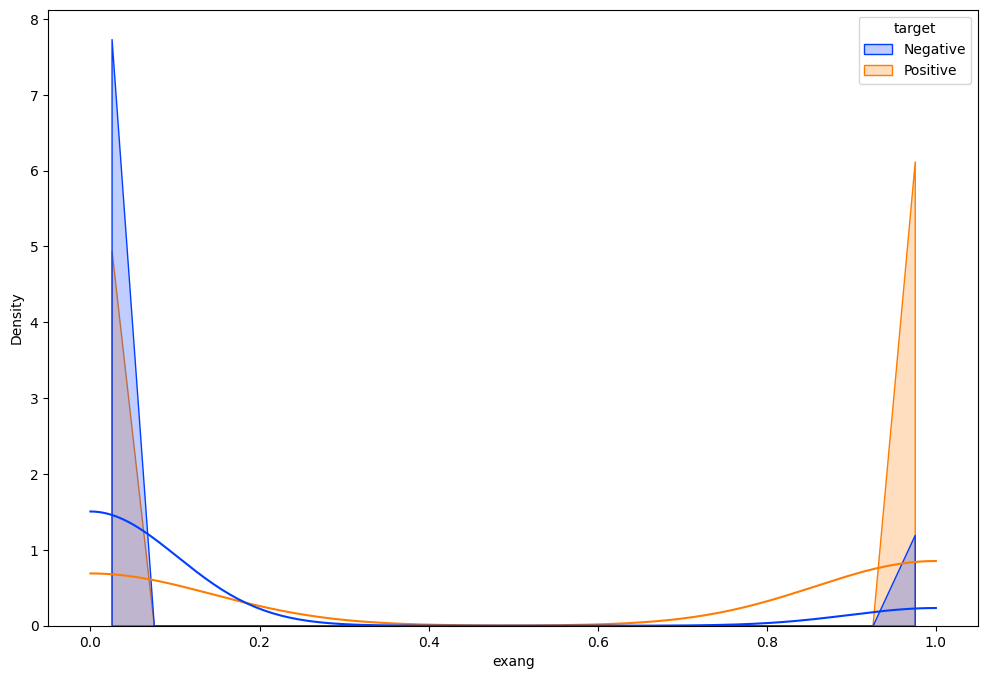

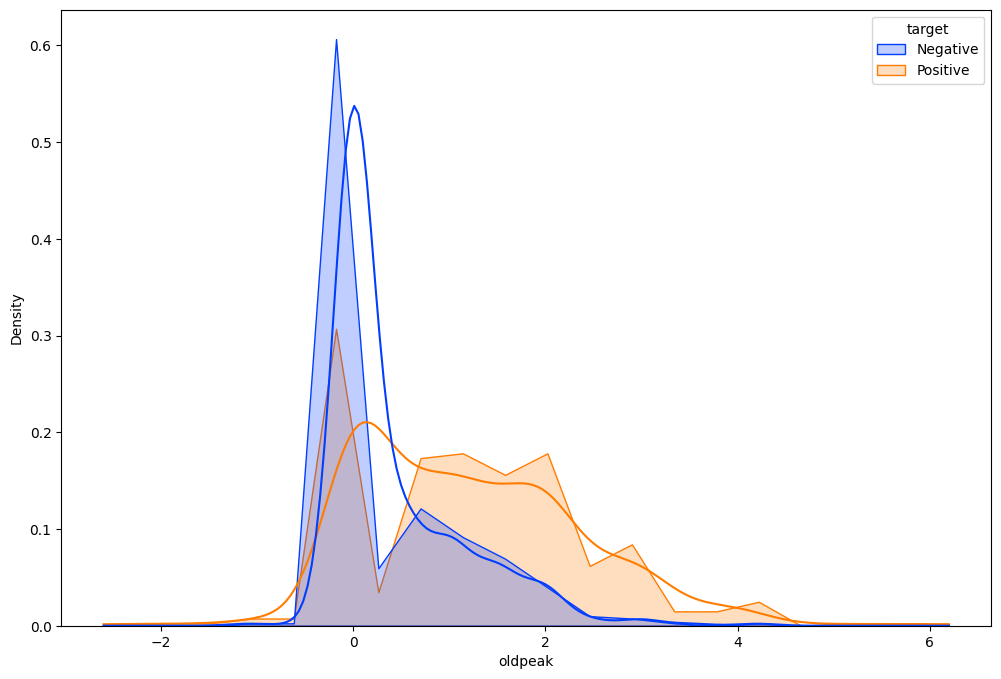

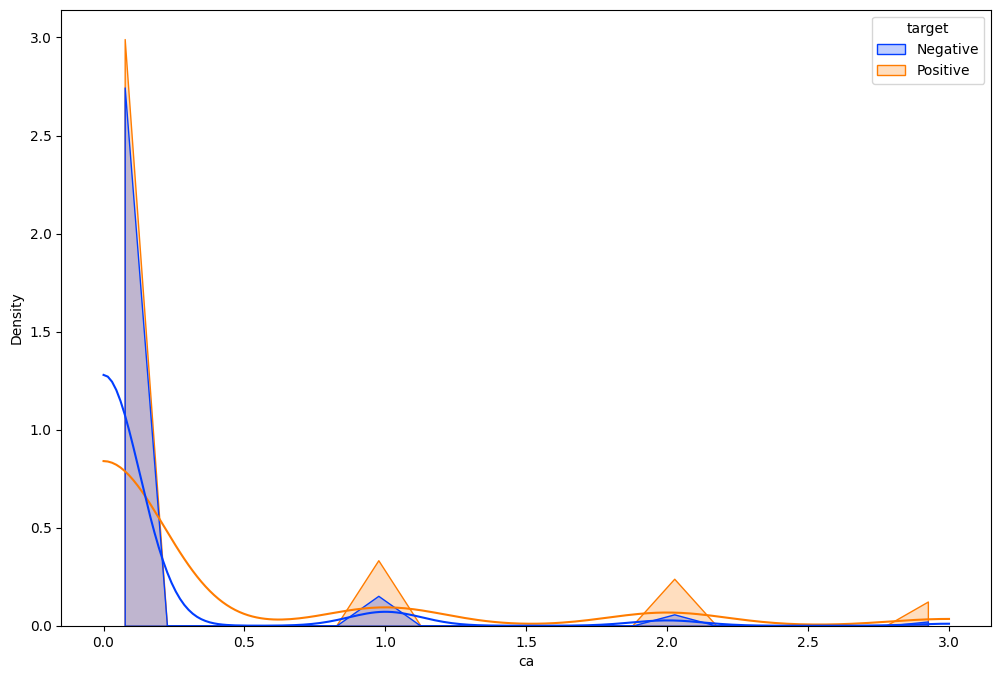

In [457]:
def hist_chart(col):
    plt.figure(figsize=(12, 8))
    sns.histplot(data=data, x=col, bins=20, kde=True, hue='target',
                 element='poly', stat='density', palette='bright')
    plt.show()

for i in data.select_dtypes(exclude='object'):
    hist_chart(i)

Create new columns

In [458]:
# Age grouping
data["age_group"] = pd.cut(data["age"], bins=[0, 12, 18, 40, 55, 80, 100],
                           labels=["child", "teenager", "young", "middle", "senior", "old"]).astype("object")

# High BP flag
data["high_bp"] = (data["trestbps"] >= 140)

# High cholesterol
data["high_chol"] = (data["chol"] >= 240)

Count chart for new columns

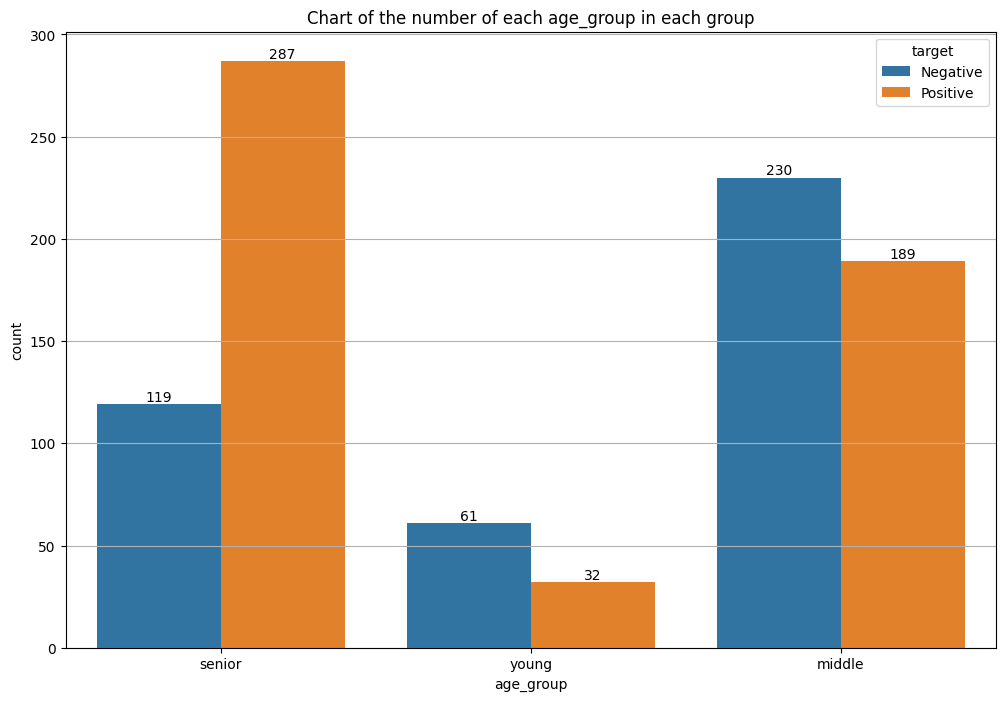

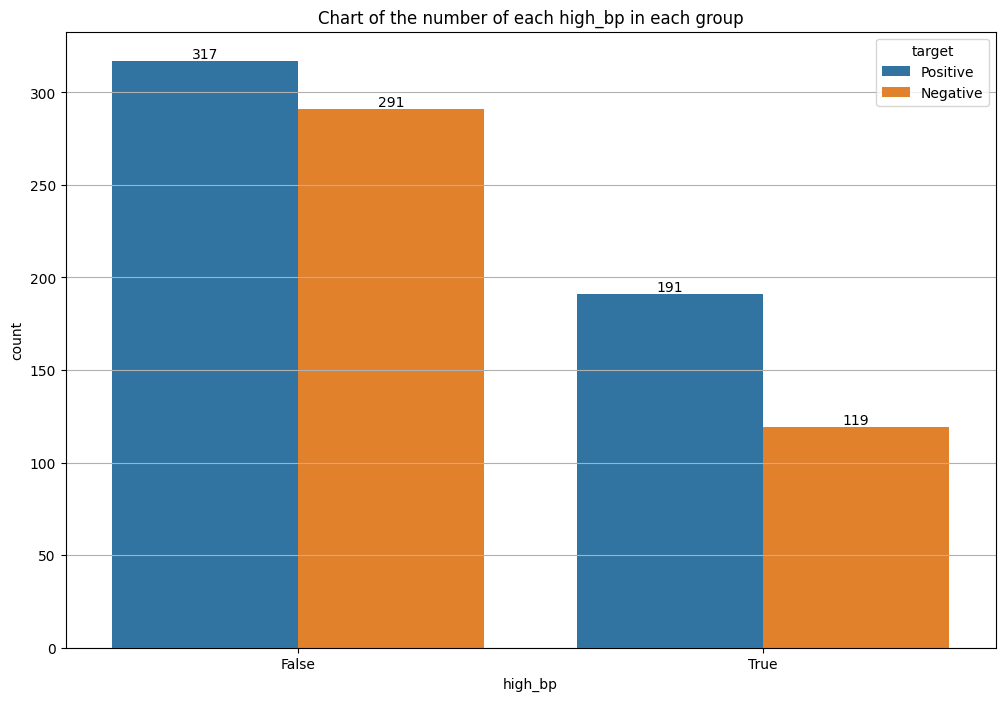

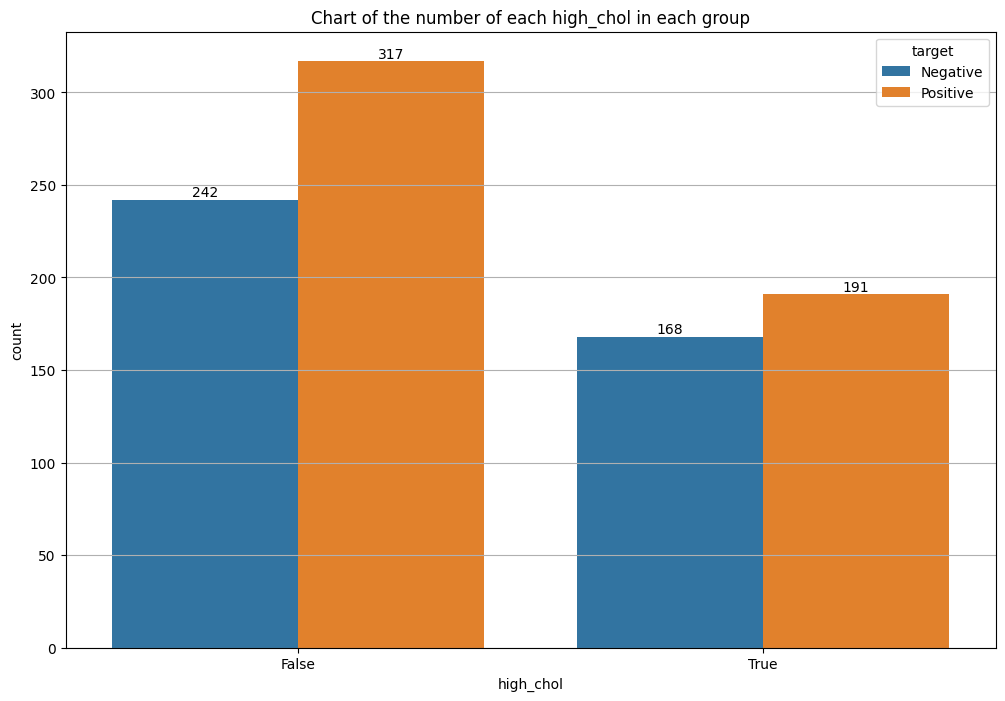

In [459]:
for i in data.iloc[:, -3:]:
    count_chart(i)

Data normalization & data sharing

In [460]:
numeric_columns = data.select_dtypes(exclude=['object', 'bool']).columns.to_list()
object_columns = data.select_dtypes(['object', 'bool']).drop('target', axis=1).columns.to_list()
y = data['target'].replace({"Negative": 0, "Positive": 1})

# standardize numerical data
scaler = StandardScaler()
x = data[numeric_columns].copy()

for i in numeric_columns:
    x[i] = scaler.fit_transform(x[[i]])

# convert text data to numeric
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

for i in object_columns:
    encoded = encoder.fit_transform(data[[i]])

    encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out([i]), index=x.index)

    x = pd.concat([x, encoded_df], axis=1)

C:\Users\Personal Computer\AppData\Local\Temp\ipykernel_12552\737595783.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = data['target'].replace({"Negative": 0, "Positive": 1})


Scatter chart

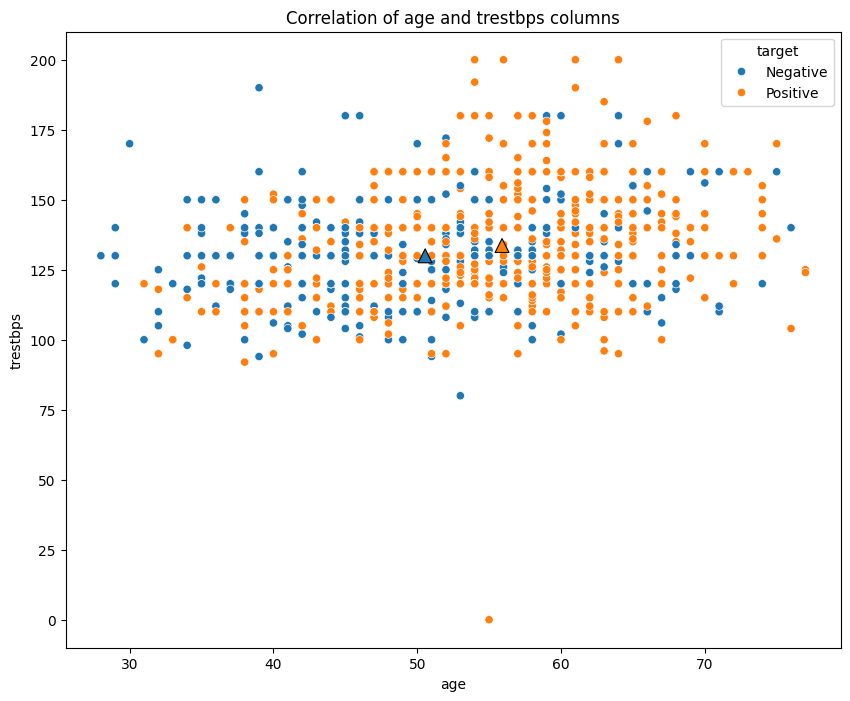

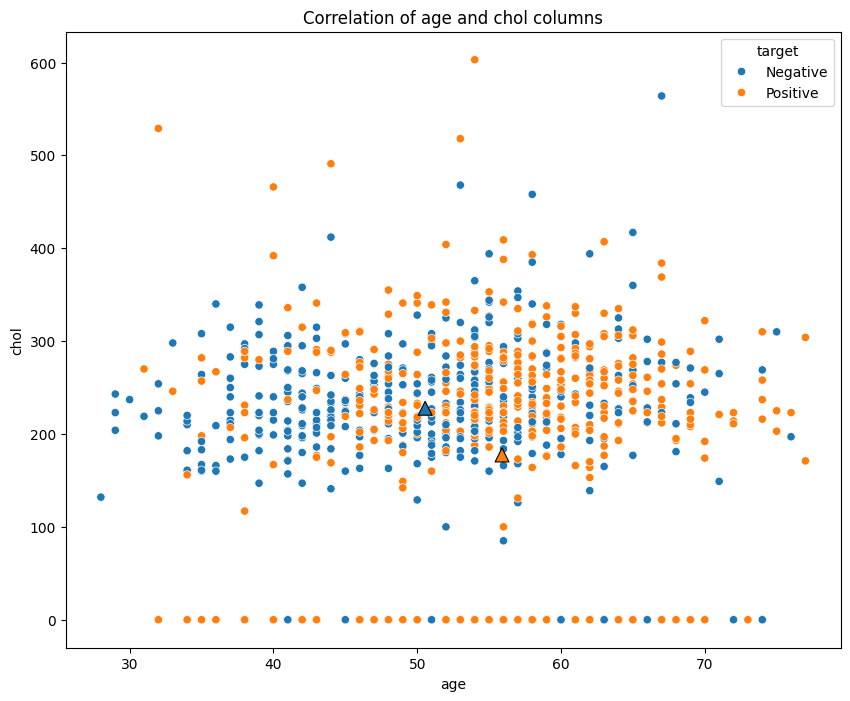

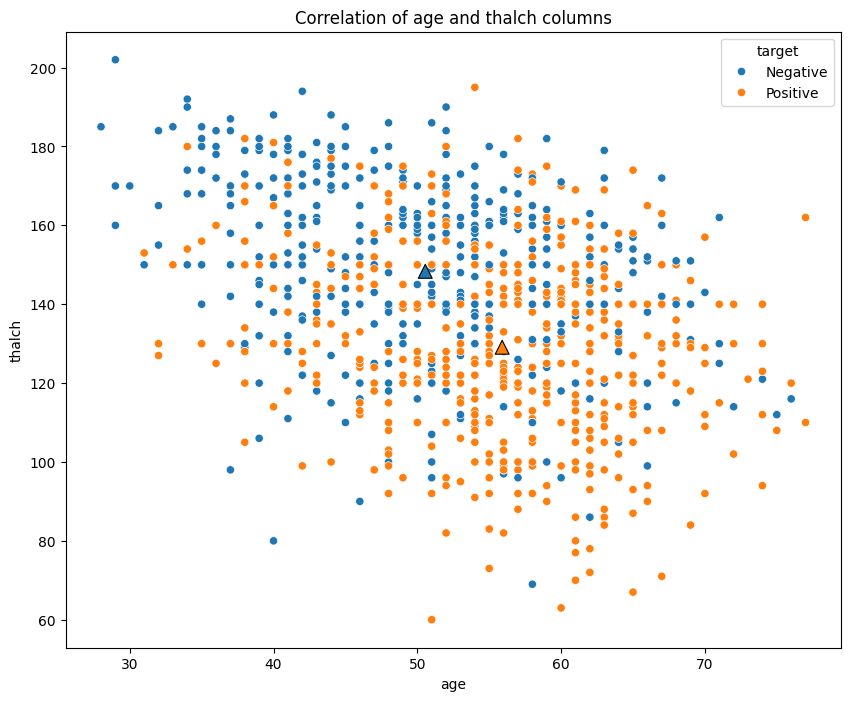

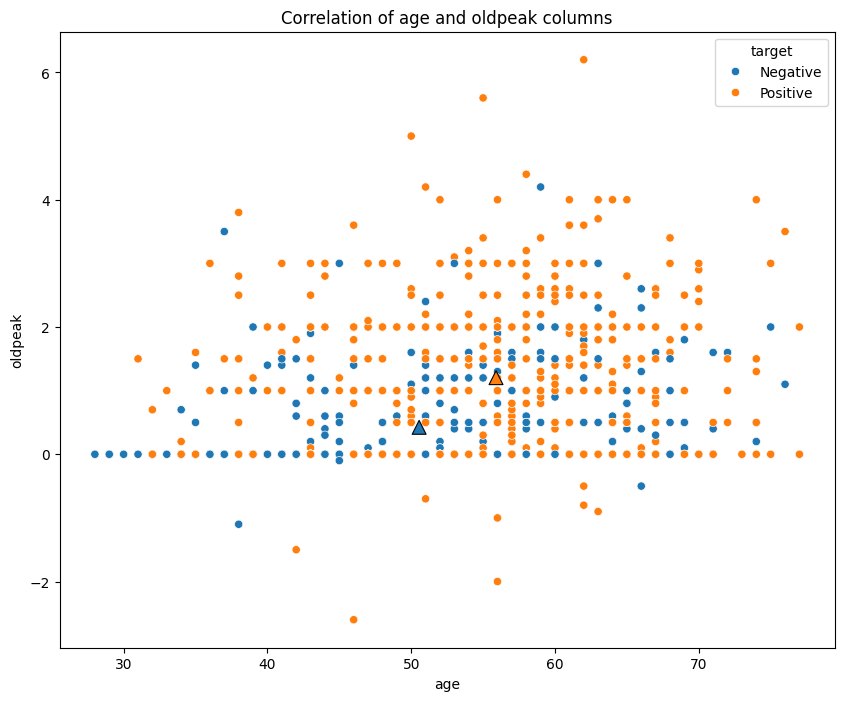

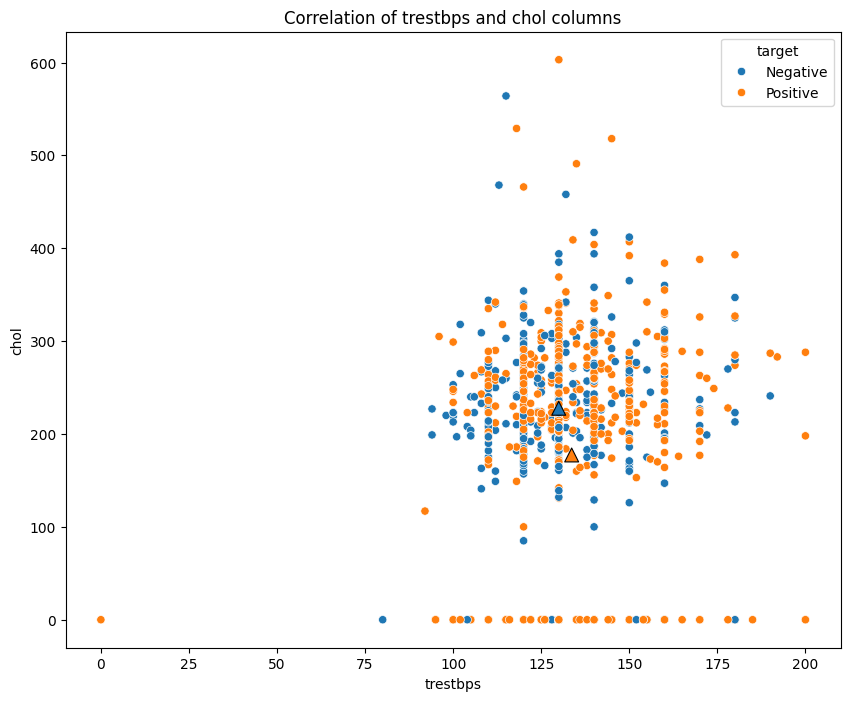

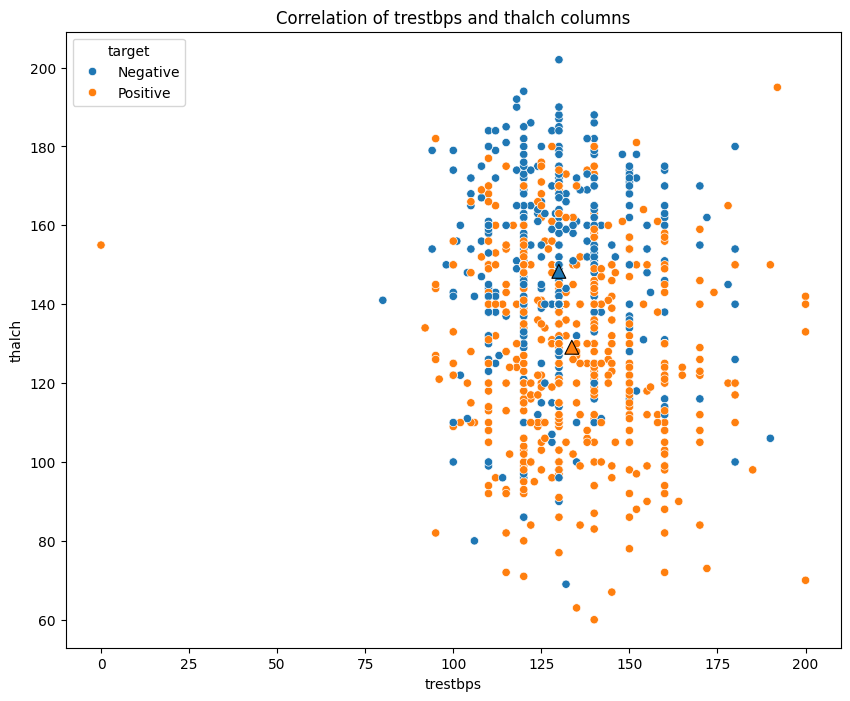

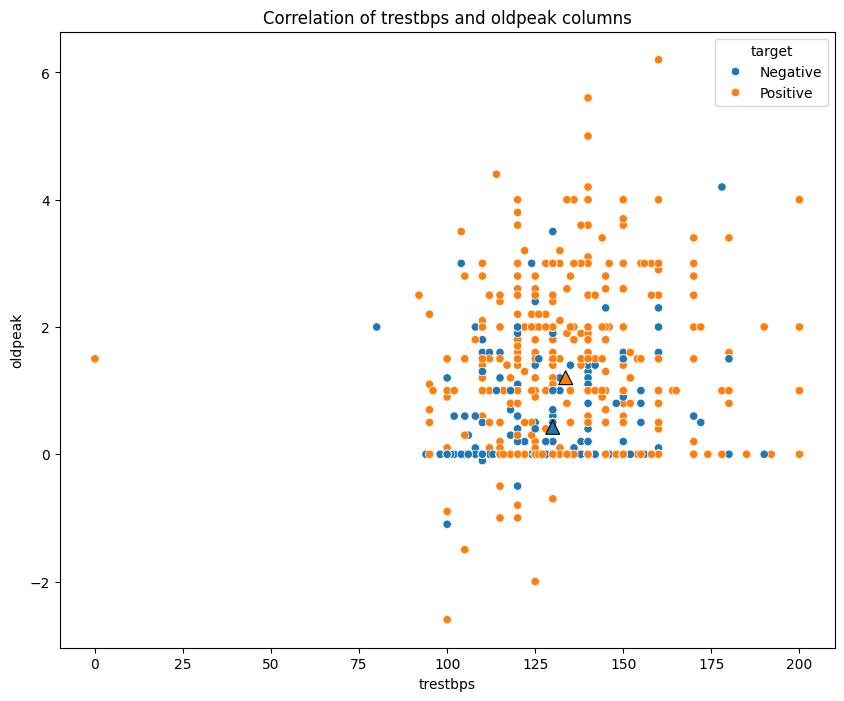

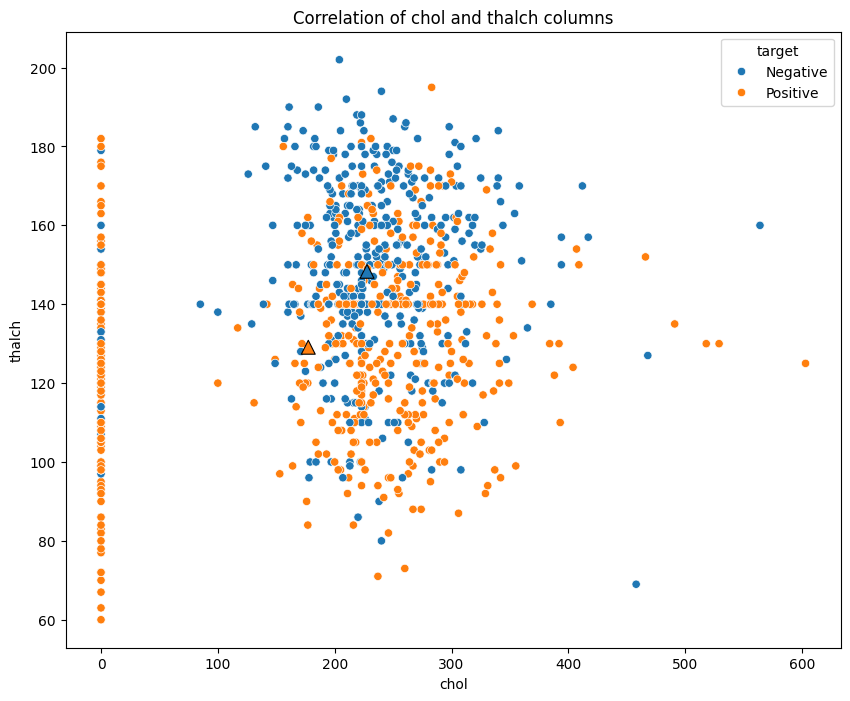

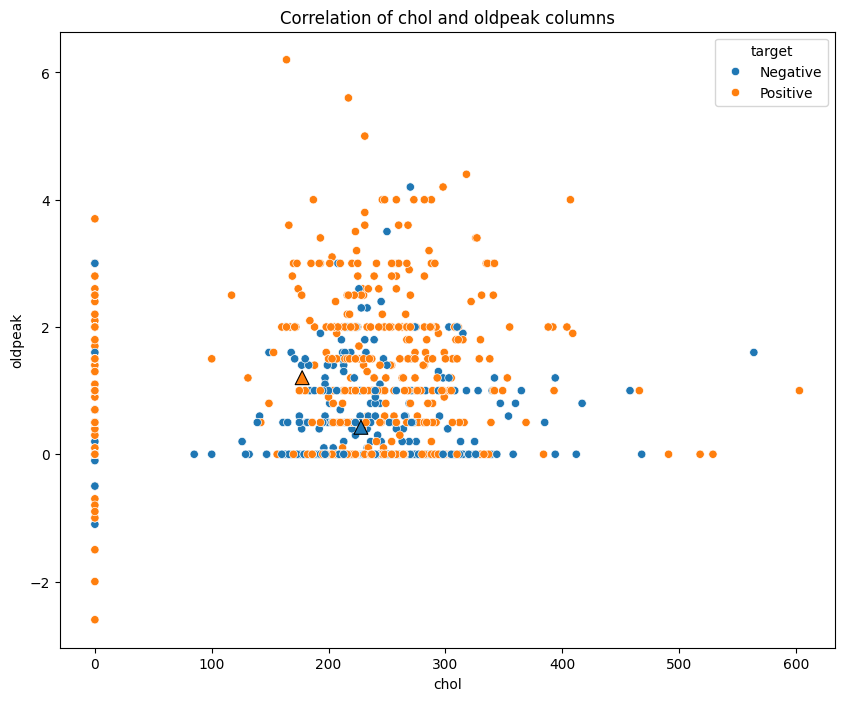

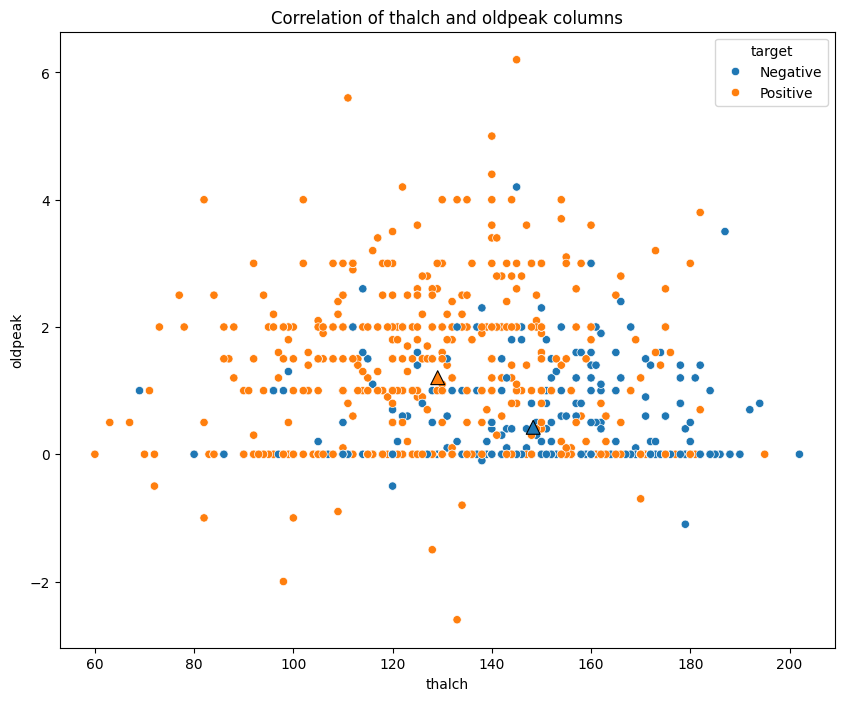

In [461]:
scatter_columns_list = [x for x in numeric_columns if x != 'ca']
list_columns = combinations(scatter_columns_list, 2)
mean_data = data.drop(object_columns, axis=1).groupby('target').mean()

def scatter_chart(col1, col2):
    axis1 = i.split('(')[0]
    axis2 = j.split('(')[0]

    plt.figure(figsize=(10, 8))
    plt.title(f"Correlation of {axis1} and {axis2} columns")
    sns.scatterplot(data=data, x=col1, y=col2, hue='target')

    sns.scatterplot(data=mean_data, x=i, y=j, hue='target', marker='^', s=100,
                    legend=False, edgecolor='black')

    plt.show()

for i, j in list_columns:
    scatter_chart(i, j)

Heatmap chart

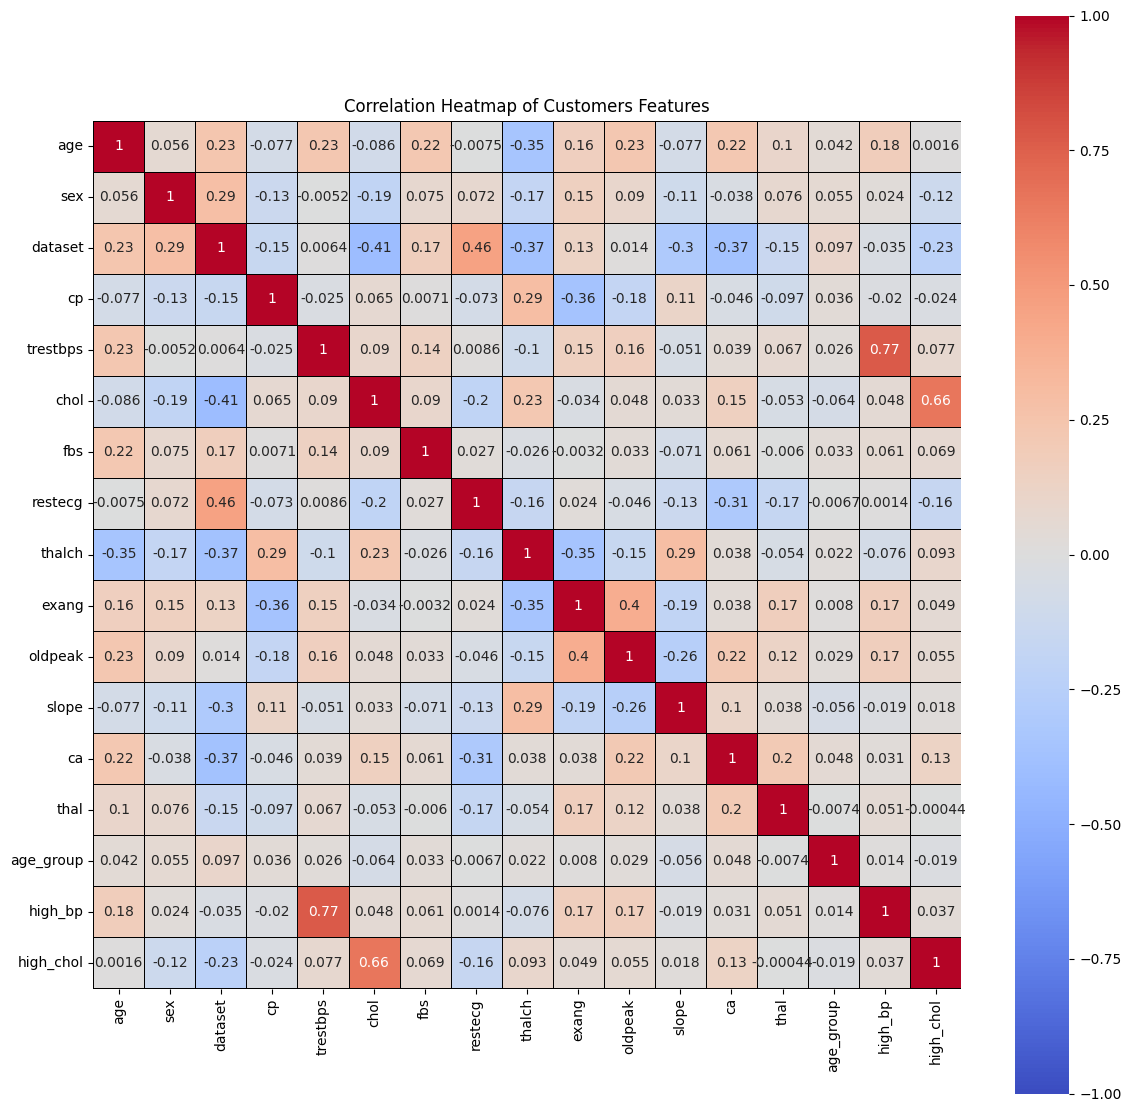

In [462]:

label_encoder = LabelEncoder()
heat_data = data.drop('target', axis=1).copy()

for i in heat_data.select_dtypes(['object', 'bool']).columns:
    heat_data[i] = label_encoder.fit_transform(data[i])

plt.figure(figsize=(14, 14))
sns.heatmap(heat_data.corr(), cmap='coolwarm', annot=True,
            linewidths=0.5, linecolor='black', square=True,
            vmin=-1, vmax=1, center=0)

plt.title("Correlation Heatmap of Customers Features")
plt.show()

Train-Test-Split

In [463]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3,
                                                    random_state=42)

Model making

In [464]:
model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
model_score = roc_auc_score(y_test, y_pred)

print(f"Accuracy of the model: {int(model_score * 100)}%")

Accuracy of the model: 80%


Strengthening the model

In [465]:
selector = SelectKBest(score_func=f_classif, k=25)
best_columns_x = selector.fit_transform(x, y)

In [466]:
x_train, x_test, y_train, y_test = train_test_split(best_columns_x, y, test_size=0.3,
                                                    random_state=42)

In [467]:
param_grid = {"n_estimators": [200, 400, 600],
              "max_depth": [None, 10, 20],
              "min_samples_leaf": [1, 3, 5],
              "max_features": ["sqrt", "log2"]}

grid = GridSearchCV(RandomForestClassifier(class_weight='balanced', random_state=42),
                          param_grid=param_grid,
                          cv=5,
                          scoring='f1',
                          n_jobs=1)

grid.fit(x_train, y_train)
best_model = grid.best_estimator_

In [468]:
best_model.fit(x_train, y_train)
y_pred = best_model.predict(x_test)
model_score = roc_auc_score(y_test, y_pred)

print(f"Model accuracy after enhancement: {int(model_score * 100)}%")

Model accuracy after enhancement: 80%
